## FED Is What FED Does

## Start With Data :

In [1]:
# ============================================================
# FED POLICY MODEL — DATA DOWNLOAD
# Frequency: Monthly macro data + daily market/policy data
# ============================================================

import os
import io
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

START = "2000-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")

DATA_DIR = "fed_policy_data"
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Downloading data from {START} to {END}")

In [2]:
# ============================================================
# 2. FRED DOWNLOADER — NO API KEY REQUIRED
# ============================================================

def get_fred_series(series_id, start=START, end=END):
    """
    Download one FRED series directly as CSV.
    No FRED API key required.
    """
    url = (
        f"https://fred.stlouisfed.org/graph/fredgraph.csv?"
        f"id={series_id}&cos=Close&coed={end}"
    )

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        df = pd.read_csv(io.StringIO(response.text))

        df.columns = ["date", series_id]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")

        df = df.dropna(subset=["date"]).sort_values("date")
        df = df[df["date"] >= pd.Timestamp(start)]

        return df.set_index("date")[[series_id]]

    except Exception as e:
        print(f"Failed: {series_id} | {e}")
        return pd.DataFrame(columns=[series_id])

In [3]:
# ============================================================
# 3. SERIES LIST
# ============================================================

FRED_SERIES = {

    # ── Fed policy rate ──────────────────────────────────────
    "fed_target_upper": "DFEDTARU",     # Fed funds target upper bound
    "fed_target_lower": "DFEDTARL",     # Fed funds target lower bound
    "effective_fed_funds": "EFFR",      # Effective Fed funds rate

    # ── Inflation ────────────────────────────────────────────
    "headline_cpi": "CPIAUCSL",         # CPI, all urban consumers
    "core_cpi": "CPILFESL",             # CPI excluding food & energy
    "headline_pce": "PCEPI",            # Headline PCE
    "core_pce": "PCEPILFE",             # Core PCE

    # ── Labour market ────────────────────────────────────────
    "unemployment_rate": "UNRATE",
    "nonfarm_payrolls": "PAYEMS",
    "avg_hourly_earnings": "CES0500000003",
    "initial_jobless_claims": "ICSA",

    # ── Growth / demand ──────────────────────────────────────
    "industrial_production": "INDPRO",
    "retail_sales": "RSAFS",
    "real_gdp": "GDPC1",

    # ── Yield curve / financial conditions ───────────────────
    "treasury_3m": "TB3MS",
    "treasury_2y": "DGS2",
    "treasury_10y": "DGS10",
    "baa_corporate_yield": "BAA",
    "financial_conditions": "NFCI",

    # ── Inflation expectations ───────────────────────────────
    "breakeven_5y": "T5YIE",
    "breakeven_10y": "T10YIE",
    "inflation_expectations_1y": "EXPINF1YR",

    # ── Dollar / global conditions ───────────────────────────
    "broad_dollar_index": "DTWEXBGS",
    "brent_oil": "DCOILBRENTEU"
}

In [4]:
# ============================================================
# 4. DOWNLOAD ALL FRED SERIES
# ============================================================

fred_data = {}

for name, series_id in FRED_SERIES.items():
    print(f"Downloading: {name} ({series_id})")

    temp = get_fred_series(series_id)

    if not temp.empty:
        temp.columns = [name]
        fred_data[name] = temp

print(f"\nSuccessfully downloaded {len(fred_data)} of {len(FRED_SERIES)} FRED series.")

Downloading: fed_target_upper (DFEDTARU)
Downloading: fed_target_lower (DFEDTARL)
Downloading: effective_fed_funds (EFFR)
Downloading: headline_cpi (CPIAUCSL)
Downloading: core_cpi (CPILFESL)
Downloading: headline_pce (PCEPI)
Downloading: core_pce (PCEPILFE)
Downloading: unemployment_rate (UNRATE)
Downloading: nonfarm_payrolls (PAYEMS)
Downloading: avg_hourly_earnings (CES0500000003)
Downloading: initial_jobless_claims (ICSA)
Downloading: industrial_production (INDPRO)
Downloading: retail_sales (RSAFS)
Downloading: real_gdp (GDPC1)
Downloading: treasury_3m (TB3MS)
Downloading: treasury_2y (DGS2)
Downloading: treasury_10y (DGS10)
Downloading: baa_corporate_yield (BAA)
Downloading: financial_conditions (NFCI)
Downloading: breakeven_5y (T5YIE)
Downloading: breakeven_10y (T10YIE)
Downloading: inflation_expectations_1y (EXPINF1YR)
Downloading: broad_dollar_index (DTWEXBGS)
Downloading: brent_oil (DCOILBRENTEU)

Successfully downloaded 24 of 24 FRED series.


In [5]:
# ============================================================
# 5. COMBINE FRED DATA INTO ONE DAILY DATASET
# ============================================================

fred_daily = pd.concat(fred_data.values(), axis=1).sort_index()

# Keep daily calendar and forward-fill slower-moving macro variables.
daily_index = pd.date_range(START, END, freq="D")

fred_daily = (
    fred_daily
    .reindex(daily_index)
    .sort_index()
    .ffill()
)

fred_daily.index.name = "date"

print(fred_daily.shape)
display(fred_daily.tail())

(9672, 24)


,fed_target_upper,fed_target_lower,effective_fed_funds,headline_cpi,core_cpi,headline_pce,core_pce,unemployment_rate,nonfarm_payrolls,avg_hourly_earnings,...,treasury_3m,treasury_2y,treasury_10y,baa_corporate_yield,financial_conditions,breakeven_5y,breakeven_10y,inflation_expectations_1y,broad_dollar_index,brent_oil
date,,,,,,,,,,,,,,,,,,,,,
2026-06-20,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,3.6,4.19,4.46,6.1,-0.505,2.27,2.25,3.019172,120.3958,84.36
2026-06-21,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,3.6,4.19,4.46,6.1,-0.505,2.27,2.25,3.019172,120.3958,84.36
2026-06-22,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,3.6,4.24,4.51,6.1,-0.505,2.28,2.23,3.019172,120.3958,84.36
2026-06-23,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,3.6,4.24,4.51,6.1,-0.505,2.24,2.21,3.019172,120.3958,84.36
2026-06-24,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,3.6,4.24,4.51,6.1,-0.505,2.24,2.21,3.019172,120.3958,84.36


In [6]:
# ============================================================
# 6. DOWNLOAD DAILY FINANCIAL MARKET DATA FROM YFINANCE
#    Robust version — clean one Series per ticker
# ============================================================

YF_TICKERS = {
    "sp500": "^GSPC",
    "vix": "^VIX",
    "dxy": "DX-Y.NYB",
    "us_2y_etf_proxy": "SHY",
    "us_10y_etf_proxy": "IEF"
}

market_series = []

for name, ticker in YF_TICKERS.items():
    print(f"Downloading Yahoo Finance data: {ticker}")

    try:
        px = yf.Ticker(ticker).history(
            start=START,
            end=END,
            auto_adjust=True
        )

        if px.empty:
            print(f"  Warning: no data returned for {ticker}")
            continue

        # Keep only adjusted close-equivalent series
        s = px["Close"].copy()

        # Make datetime index consistent and timezone-free
        s.index = pd.to_datetime(s.index).tz_localize(None).normalize()

        # Remove duplicate trading dates
        s = s[~s.index.duplicated(keep="last")]

        # Rename before combining
        s.name = name

        market_series.append(s)

        print(f"  Success: {len(s):,} observations "
              f"({s.index.min().date()} to {s.index.max().date()})")

    except Exception as e:
        print(f"  Failed: {ticker} | {e}")

# Combine all clean price series
market_data = pd.concat(market_series, axis=1).sort_index()

market_data.index.name = "date"

print("\nFinal market-data shape:", market_data.shape)
display(market_data.tail(10))

  Success: 6,657 observations (2000-01-03 to 2026-06-23)
  Success: 6,658 observations (2000-01-03 to 2026-06-23)
  Success: 6,686 observations (2000-01-03 to 2026-06-23)
  Success: 6,013 observations (2002-07-30 to 2026-06-23)
  Success: 6,013 observations (2002-07-30 to 2026-06-23)

Final market-data shape: (6689, 5)


,sp500,vix,dxy,us_2y_etf_proxy,us_10y_etf_proxy
date,,,,,
2026-06-09,7386.649902,19.870001,99.910004,81.940002,93.779999
2026-06-10,7266.990234,22.219999,99.949997,81.940002,93.690002
2026-06-11,7394.299805,19.440001,99.860001,82.089996,94.339996
2026-06-12,7431.459961,17.680000,99.750000,82.070000,94.180000
2026-06-15,7554.290039,16.200001,99.629997,82.110001,94.279999
2026-06-16,7511.350098,16.410000,99.540001,82.129997,94.519997
2026-06-17,7420.100098,18.440001,100.089996,81.879997,94.019997
2026-06-18,7500.580078,16.400000,100.849998,81.989998,94.360001
2026-06-22,7472.790039,17.280001,101.019997,81.910004,94.000000


In [7]:
# ============================================================
# 7. CREATE DAILY MARKET FEATURES
# ============================================================

market_features = market_data.copy()

# Equity market return
market_features["sp500_return_1d"]  = market_features["sp500"].pct_change(1) * 100
market_features["sp500_return_21d"] = market_features["sp500"].pct_change(21) * 100

# VIX changes
market_features["vix_change_5d"]  = market_features["vix"].pct_change(5) * 100
market_features["vix_change_21d"] = market_features["vix"].pct_change(21) * 100

# Dollar changes
market_features["dxy_change_21d"] = market_features["dxy"].pct_change(21) * 100

# Treasury ETF changes as a market-based duration signal
market_features["shy_return_21d"] = market_features["us_2y_etf_proxy"].pct_change(21) * 100
market_features["ief_return_21d"] = market_features["us_10y_etf_proxy"].pct_change(21) * 100

display(market_features.tail())

,sp500,vix,dxy,us_2y_etf_proxy,us_10y_etf_proxy,sp500_return_1d,sp500_return_21d,vix_change_5d,vix_change_21d,dxy_change_21d,shy_return_21d,ief_return_21d
date,,,,,,,,,,,,
2026-06-16,7511.350098,16.410000,99.540001,82.129997,94.519997,-0.568418,1.462915,-17.413190,-7.912457,0.575932,0.332782,1.463170
2026-06-17,7420.100098,18.440001,100.089996,81.879997,94.019997,-1.214828,0.904185,-17.011696,2.104103,0.795562,0.100528,1.316664
2026-06-18,7500.580078,16.400000,100.849998,81.989998,94.360001,1.084621,0.909594,-15.637864,-5.963308,1.755623,0.100794,0.999670
2026-06-22,7472.790039,17.280001,101.019997,81.910004,94.000000,-0.370505,0.363562,-2.262441,3.102628,1.844938,0.015306,0.549979
2026-06-23,7365.459961,19.490000,101.410004,81.970001,94.120003,-1.436279,-1.445249,20.308635,16.706580,2.104313,0.112935,0.592556


In [8]:
# ============================================================
# 8. MERGE MACRO + POLICY + MARKET DATA
# ============================================================

fed_master_daily = (
    fred_daily
    .join(market_features, how="left")
    .sort_index()
    .ffill()
)

# Yield curve and policy gap variables
fed_master_daily["yield_curve_10y_2y"] = (
    fed_master_daily["treasury_10y"]
    - fed_master_daily["treasury_2y"]
)

fed_master_daily["yield_curve_10y_3m"] = (
    fed_master_daily["treasury_10y"]
    - fed_master_daily["treasury_3m"]
)

fed_master_daily["policy_rate_gap_2y"] = (
    fed_master_daily["treasury_2y"]
    - fed_master_daily["fed_target_upper"]
)

# Policy target rate change in basis points
fed_master_daily["fed_rate_change_bp"] = (
    fed_master_daily["fed_target_upper"]
    .diff()
    * 100
)

# Mark actual policy-change days
fed_master_daily["policy_changed"] = (
    fed_master_daily["fed_rate_change_bp"]
    .fillna(0)
    .ne(0)
    .astype(int)
)

display(fed_master_daily.tail())

,fed_target_upper,fed_target_lower,effective_fed_funds,headline_cpi,core_cpi,headline_pce,core_pce,unemployment_rate,nonfarm_payrolls,avg_hourly_earnings,...,vix_change_5d,vix_change_21d,dxy_change_21d,shy_return_21d,ief_return_21d,yield_curve_10y_2y,yield_curve_10y_3m,policy_rate_gap_2y,fed_rate_change_bp,policy_changed
date,,,,,,,,,,,,,,,,,,,,,
2026-06-20,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,-15.637864,-5.963308,1.755623,0.100794,0.999670,0.27,0.86,0.44,0.0,0
2026-06-21,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,-15.637864,-5.963308,1.755623,0.100794,0.999670,0.27,0.86,0.44,0.0,0
2026-06-22,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,-2.262441,3.102628,1.844938,0.015306,0.549979,0.27,0.91,0.49,0.0,0
2026-06-23,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,20.308635,16.706580,2.104313,0.112935,0.592556,0.27,0.91,0.49,0.0,0
2026-06-24,3.75,3.5,3.63,333.979,336.121,130.902,129.63,4.3,159001.0,37.53,...,20.308635,16.706580,2.104313,0.112935,0.592556,0.27,0.91,0.49,0.0,0


In [9]:
# ============================================================
# 9. CREATE MONTHLY MACRO FEATURES
# ============================================================

fed_monthly = fed_master_daily.resample("ME").last().copy()

# Inflation rates
for col in ["headline_cpi", "core_cpi", "headline_pce", "core_pce"]:
    fed_monthly[f"{col}_yoy"] = fed_monthly[col].pct_change(12) * 100
    fed_monthly[f"{col}_3m_ann"] = (
        ((fed_monthly[col] / fed_monthly[col].shift(3)) ** 4 - 1) * 100
    )

# Labour-market growth
fed_monthly["payroll_growth_3m"] = (
    fed_monthly["nonfarm_payrolls"]
    .pct_change(3)
    * 100
)

fed_monthly["wage_growth_yoy"] = (
    fed_monthly["avg_hourly_earnings"]
    .pct_change(12)
    * 100
)

# Growth variables
fed_monthly["industrial_production_yoy"] = (
    fed_monthly["industrial_production"]
    .pct_change(12)
    * 100
)

fed_monthly["retail_sales_yoy"] = (
    fed_monthly["retail_sales"]
    .pct_change(12)
    * 100
)

# Oil inflation
fed_monthly["brent_oil_yoy"] = (
    fed_monthly["brent_oil"]
    .pct_change(12)
    * 100
)

# Change in unemployment
fed_monthly["unemployment_change_3m"] = (
    fed_monthly["unemployment_rate"]
    .diff(3)
)

# Policy rate move over previous three months
fed_monthly["fed_rate_change_3m_bp"] = (
    fed_monthly["fed_target_upper"]
    .diff(3)
    * 100
)

display(fed_monthly.tail())

,fed_target_upper,fed_target_lower,effective_fed_funds,headline_cpi,core_cpi,headline_pce,core_pce,unemployment_rate,nonfarm_payrolls,avg_hourly_earnings,...,headline_pce_3m_ann,core_pce_yoy,core_pce_3m_ann,payroll_growth_3m,wage_growth_yoy,industrial_production_yoy,retail_sales_yoy,brent_oil_yoy,unemployment_change_3m,fed_rate_change_3m_bp
date,,,,,,,,,,,,,,,,,,,,,
2026-02-28,3.75,3.5,3.64,327.460,333.512,129.520,128.940,4.4,158436.0,37.27,...,4.338788,3.032482,4.696545,-0.008205,3.700612,0.840758,4.174261,-4.601391,-0.1,-25.0
2026-03-31,3.75,3.5,3.64,330.293,334.165,130.381,129.321,4.3,158650.0,37.35,...,5.734712,3.236287,4.564485,0.137598,3.433952,0.580857,4.240612,64.042471,-0.1,0.0
2026-04-30,3.75,3.5,3.64,332.407,335.423,130.902,129.630,4.3,158829.0,37.41,...,6.022821,3.289191,3.783689,0.149440,3.571429,1.365696,4.788481,96.054916,0.0,0.0
2026-05-31,3.75,3.5,3.62,333.979,336.121,130.902,129.630,4.3,159001.0,37.53,...,4.336865,3.052707,2.157774,0.356611,3.445424,1.665916,6.876462,44.402985,-0.1,0.0
2026-06-30,3.75,3.5,3.63,333.979,336.121,130.902,129.630,4.3,159001.0,37.53,...,1.607999,2.782249,0.959192,0.221242,3.217822,1.151968,5.625193,23.785767,0.0,0.0


In [10]:
# ============================================================
# 10. SAVE CLEAN DATASETS
# ============================================================

fred_daily.to_csv(f"{DATA_DIR}/fred_daily_raw.csv")
market_data.to_csv(f"{DATA_DIR}/market_data_raw.csv")
fed_master_daily.to_csv(f"{DATA_DIR}/fed_master_daily.csv")
fed_monthly.to_csv(f"{DATA_DIR}/fed_monthly_features.csv")

print("Saved files:")
print(f"1. {DATA_DIR}/fred_daily_raw.csv")
print(f"2. {DATA_DIR}/market_data_raw.csv")
print(f"3. {DATA_DIR}/fed_master_daily.csv")
print(f"4. {DATA_DIR}/fed_monthly_features.csv")

Saved files:
1. fed_policy_data/fred_daily_raw.csv
2. fed_policy_data/market_data_raw.csv
3. fed_policy_data/fed_master_daily.csv
4. fed_policy_data/fed_monthly_features.csv


In [11]:
# ============================================================
# 11. CHECK ACTUAL FED POLICY CHANGE DATES
# ============================================================

policy_moves = (
    fed_master_daily.loc[
        fed_master_daily["policy_changed"] == 1,
        [
            "fed_target_lower",
            "fed_target_upper",
            "fed_rate_change_bp",
            "effective_fed_funds"
        ]
    ]
    .copy()
)

policy_moves["decision"] = np.select(
    [
        policy_moves["fed_rate_change_bp"] < 0,
        policy_moves["fed_rate_change_bp"] > 0
    ],
    [
        "Cut",
        "Hike"
    ],
    default="Hold"
)

display(policy_moves.tail(30))

,fed_target_lower,fed_target_upper,fed_rate_change_bp,effective_fed_funds,decision
date,,,,,
2016-12-14,0.50,0.75,25.0,0.41,Hike
2017-03-16,0.75,1.00,25.0,0.91,Hike
2017-06-15,1.00,1.25,25.0,1.16,Hike
2017-12-14,1.25,1.50,25.0,1.41,Hike
2018-03-22,1.50,1.75,25.0,1.68,Hike
2018-06-14,1.75,2.00,25.0,1.90,Hike
2018-09-27,2.00,2.25,25.0,2.18,Hike
2018-12-20,2.25,2.50,25.0,2.40,Hike
2019-08-01,2.00,2.25,-25.0,2.14,Cut


## Ok lets work on the model Building 

In [12]:
# ============================================================
# FED POLICY MODEL
# Direct monthly forecasts of Fed target-rate changes
# Horizons: 1M, 2M, 3M, 6M
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [13]:
# ============================================================
# 1. BASIC DATA CHECK
# ============================================================

df = fed_monthly.copy().sort_index()

# Make index clean monthly timestamps
df.index = pd.to_datetime(df.index)
df = df[~df.index.duplicated(keep="last")].sort_index()

required_cols = [
    "fed_target_upper",
    "core_pce_yoy",
    "core_cpi_yoy",
    "unemployment_rate",
    "sp500_return_21d",
    "vix",
    "treasury_2y",
    "treasury_10y"
]

missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    print("Missing columns:", missing_required)
else:
    print("All core columns are available.")

print("Dataset period:", df.index.min().date(), "to", df.index.max().date())
print("Observations:", len(df))
display(df.tail())

All core columns are available.
Dataset period: 2000-01-31 to 2026-06-30
Observations: 318


,fed_target_upper,fed_target_lower,effective_fed_funds,headline_cpi,core_cpi,headline_pce,core_pce,unemployment_rate,nonfarm_payrolls,avg_hourly_earnings,initial_jobless_claims,industrial_production,retail_sales,real_gdp,treasury_3m,treasury_2y,treasury_10y,baa_corporate_yield,financial_conditions,breakeven_5y,breakeven_10y,inflation_expectations_1y,broad_dollar_index,brent_oil,sp500,vix,dxy,us_2y_etf_proxy,us_10y_etf_proxy,sp500_return_1d,sp500_return_21d,vix_change_5d,vix_change_21d,dxy_change_21d,shy_return_21d,ief_return_21d,yield_curve_10y_2y,yield_curve_10y_3m,policy_rate_gap_2y,fed_rate_change_bp,policy_changed,headline_cpi_yoy,headline_cpi_3m_ann,core_cpi_yoy,core_cpi_3m_ann,headline_pce_yoy,headline_pce_3m_ann,core_pce_yoy,core_pce_3m_ann,payroll_growth_3m,wage_growth_yoy,industrial_production_yoy,retail_sales_yoy,brent_oil_yoy,unemployment_change_3m,fed_rate_change_3m_bp
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-02-28,3.750,3.500,3.640,327.460,333.512,129.520,128.940,4.400,"158,436.000",37.270,"214,000.000",101.949,"741,278.000","24,152.656",3.600,3.380,3.970,5.810,-0.504,2.400,2.250,2.586,117.822,71.320,"6,878.880",19.860,97.610,82.222,96.737,-0.434,-1.421,4.034,21.468,1.203,0.653,2.513,0.590,0.370,-0.370,0.000,0,2.434,2.982,2.472,3.017,2.858,4.339,3.032,4.697,-0.008,3.701,0.841,4.174,-4.601,-0.100,-25.000
2026-03-31,3.750,3.500,3.640,330.293,334.165,130.381,129.321,4.300,"158,650.000",37.350,"203,000.000",101.627,"754,013.000","24,152.656",3.610,3.790,4.300,6.040,-0.454,2.540,2.300,2.295,121.035,126.690,"6,528.520",25.250,99.960,81.838,94.493,2.913,-5.131,-6.308,17.771,1.606,-0.290,-1.730,0.510,0.690,0.040,0.000,0,3.286,5.332,2.602,2.864,3.525,5.735,3.236,4.564,0.138,3.434,0.581,4.241,64.042,-0.100,0.000
2026-04-30,3.750,3.500,3.640,332.407,335.423,130.902,129.630,4.300,"158,829.000",37.410,"190,000.000",102.509,"757,036.000","24,152.656",3.610,3.880,4.400,6.030,-0.487,2.670,2.460,3.276,118.671,124.240,"7,209.010",16.890,98.080,81.994,94.351,1.024,10.423,-12.532,-33.109,-1.881,0.191,-0.150,0.520,0.790,0.130,0.000,0,3.779,7.320,2.743,3.199,3.767,6.023,3.289,3.784,0.149,3.571,1.366,4.788,96.055,0.000,0.000
2026-05-31,3.750,3.500,3.620,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"225,000.000",102.647,"763,705.000","24,152.656",3.600,3.980,4.450,6.100,-0.504,2.520,2.380,3.535,118.878,92.880,"7,580.060",15.320,98.910,82.057,94.333,0.217,5.147,-8.263,-9.295,0.846,0.077,-0.019,0.470,0.850,0.230,0.000,0,4.167,8.204,2.823,3.166,3.578,4.337,3.053,2.158,0.357,3.445,1.666,6.876,44.403,-0.100,0.000
2026-06-30,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.240,4.510,6.100,-0.505,2.240,2.210,3.019,120.396,84.360,"7,365.460",19.490,101.410,81.970,94.120,-1.436,-1.445,20.309,16.707,2.104,0.113,0.593,0.270,0.910,0.490,0.000,0,3.902,4.539,2.583,2.362,3.281,1.608,2.782,0.959,0.221,3.218,1.152,5.625,23.786,0.000,0.000


In [14]:
# ============================================================
# 2. CREATE CLEAN POLICY FEATURES
# IMPORTANT:
# Macro variables are lagged by one month to reduce look-ahead bias.
# Financial-market variables remain contemporaneous at month-end.
# ============================================================

model_df = df.copy()

# ------------------------------------------------------------
# Inflation block
# ------------------------------------------------------------

inflation_vars = [
    "headline_cpi_yoy",
    "core_cpi_yoy",
    "headline_pce_yoy",
    "core_pce_yoy",
    "headline_cpi_3m_ann",
    "core_cpi_3m_ann",
    "headline_pce_3m_ann",
    "core_pce_3m_ann",
    "breakeven_5y",
    "breakeven_10y",
    "inflation_expectations_1y",
    "brent_oil_yoy"
]

# ------------------------------------------------------------
# Labour-market block
# ------------------------------------------------------------

labour_vars = [
    "unemployment_rate",
    "unemployment_change_3m",
    "payroll_growth_3m",
    "wage_growth_yoy",
    "initial_jobless_claims"
]

# ------------------------------------------------------------
# Growth block
# ------------------------------------------------------------

growth_vars = [
    "industrial_production_yoy",
    "retail_sales_yoy",
    "real_gdp"
]

# ------------------------------------------------------------
# Financial-condition block
# ------------------------------------------------------------

financial_vars = [
    "treasury_3m",
    "treasury_2y",
    "treasury_10y",
    "yield_curve_10y_2y",
    "yield_curve_10y_3m",
    "policy_rate_gap_2y",
    "baa_corporate_yield",
    "financial_conditions",
    "sp500_return_21d",
    "vix",
    "vix_change_5d",
    "vix_change_21d",
    "dxy_change_21d"
]

# Keep only variables that actually exist
inflation_vars = [x for x in inflation_vars if x in model_df.columns]
labour_vars = [x for x in labour_vars if x in model_df.columns]
growth_vars = [x for x in growth_vars if x in model_df.columns]
financial_vars = [x for x in financial_vars if x in model_df.columns]

macro_vars = inflation_vars + labour_vars + growth_vars

# Lag macro variables by one month.
# This prevents using values that were not yet publicly released.
for col in macro_vars:
    model_df[f"{col}_lag1"] = model_df[col].shift(1)

# Keep financial indicators at month-end.
# These are observable before the next month's decision period.
for col in financial_vars:
    model_df[f"{col}_current"] = model_df[col]

# ------------------------------------------------------------
# Policy inertia variables
# ------------------------------------------------------------

model_df["policy_rate_level"] = model_df["fed_target_upper"]
model_df["policy_rate_change_1m_bp"] = (
    model_df["fed_target_upper"].diff(1) * 100
)

model_df["policy_rate_change_3m_bp"] = (
    model_df["fed_target_upper"].diff(3) * 100
)

model_df["months_since_last_move"] = (
    model_df["policy_rate_change_1m_bp"]
    .ne(0)
    .cumsum()
    .groupby(lambda x: x)
    .cumcount()
)

# Better version of months since last policy move
last_move_month = pd.Series(
    np.where(
        model_df["policy_rate_change_1m_bp"].fillna(0).ne(0),
        np.arange(len(model_df)),
        np.nan
    ),
    index=model_df.index
).ffill()

model_df["months_since_last_move"] = (
    np.arange(len(model_df)) - last_move_month
)

model_df["months_since_last_move"] = (
    model_df["months_since_last_move"]
    .replace([np.inf, -np.inf], np.nan)
)

# Inflation gaps from Fed target
if "core_pce_yoy_lag1" in model_df.columns:
    model_df["core_pce_gap_from_2pct"] = (
        model_df["core_pce_yoy_lag1"] - 2.0
    )

if "core_cpi_yoy_lag1" in model_df.columns:
    model_df["core_cpi_gap_from_2pct"] = (
        model_df["core_cpi_yoy_lag1"] - 2.0
    )

# Labour stress proxy
if "unemployment_change_3m_lag1" in model_df.columns:
    model_df["labour_weakness_signal"] = (
        model_df["unemployment_change_3m_lag1"]
    )

print("Feature preparation complete.")

Feature preparation complete.


In [15]:
# ============================================================
# 3. FINAL FEATURE LIST
# ============================================================

feature_cols = (
    [f"{x}_lag1" for x in macro_vars] +
    [f"{x}_current" for x in financial_vars] +
    [
        "policy_rate_level",
        "policy_rate_change_1m_bp",
        "policy_rate_change_3m_bp",
        "months_since_last_move",
        "core_pce_gap_from_2pct",
        "core_cpi_gap_from_2pct",
        "labour_weakness_signal"
    ]
)

feature_cols = [x for x in feature_cols if x in model_df.columns]

print("Number of candidate features:", len(feature_cols))
print(feature_cols)

Number of candidate features: 40
['headline_cpi_yoy_lag1', 'core_cpi_yoy_lag1', 'headline_pce_yoy_lag1', 'core_pce_yoy_lag1', 'headline_cpi_3m_ann_lag1', 'core_cpi_3m_ann_lag1', 'headline_pce_3m_ann_lag1', 'core_pce_3m_ann_lag1', 'breakeven_5y_lag1', 'breakeven_10y_lag1', 'inflation_expectations_1y_lag1', 'brent_oil_yoy_lag1', 'unemployment_rate_lag1', 'unemployment_change_3m_lag1', 'payroll_growth_3m_lag1', 'wage_growth_yoy_lag1', 'initial_jobless_claims_lag1', 'industrial_production_yoy_lag1', 'retail_sales_yoy_lag1', 'real_gdp_lag1', 'treasury_3m_current', 'treasury_2y_current', 'treasury_10y_current', 'yield_curve_10y_2y_current', 'yield_curve_10y_3m_current', 'policy_rate_gap_2y_current', 'baa_corporate_yield_current', 'financial_conditions_current', 'sp500_return_21d_current', 'vix_current', 'vix_change_5d_current', 'vix_change_21d_current', 'dxy_change_21d_current', 'policy_rate_level', 'policy_rate_change_1m_bp', 'policy_rate_change_3m_bp', 'months_since_last_move', 'core_pce_g

In [16]:
# ============================================================
# 4. TARGET CREATION
# Direct forecasts:
# h=1  -> rate change over next month
# h=2  -> cumulative rate change over next 2 months
# h=3  -> cumulative rate change over next 3 months
# h=6  -> cumulative rate change over next 6 months
# ============================================================

def create_policy_targets(data, horizon_months):
    
    out = data.copy()
    
    out[f"target_change_{horizon_months}m_bp"] = (
        out["fed_target_upper"].shift(-horizon_months)
        - out["fed_target_upper"]
    ) * 100
    
    out[f"target_direction_{horizon_months}m"] = np.select(
        [
            out[f"target_change_{horizon_months}m_bp"] < 0,
            out[f"target_change_{horizon_months}m_bp"] > 0
        ],
        [
            "Cut",
            "Hike"
        ],
        default="Hold"
    )
    
    # Keep missing targets as missing, rather than incorrectly assigning Hold
    out.loc[
        out[f"target_change_{horizon_months}m_bp"].isna(),
        f"target_direction_{horizon_months}m"
    ] = np.nan
    
    return out

In [20]:
# ============================================================
# 5. TRAINING FUNCTION
# Classifier: Cut / Hold / Hike probabilities
# Regression: Expected basis-point change
# ============================================================

def train_fed_policy_model(data, horizon_months, features, train_end=None):
    
    data_h = create_policy_targets(data, horizon_months).copy()
    
    target_change = f"target_change_{horizon_months}m_bp"
    target_direction = f"target_direction_{horizon_months}m"
    
    # Use rows where target is known for training
    train_df = data_h.dropna(subset=[target_change]).copy()
    
    if train_end is not None:
        train_df = train_df.loc[:train_end].copy()
    
    X_train = train_df[features]
    y_class = train_df[target_direction]
    y_bp = train_df[target_change]
    
    # Probability model
    classifier = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            C=0.5,
            random_state=42
        ))
    ])
    
    classifier.fit(X_train, y_class)
    
    # Expected basis-point change model
    regressor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-3, 4, 80)
        ))
    ])
    
    regressor.fit(X_train, y_bp)
    
    return {
        "data": data_h,
        "classifier": classifier,
        "regressor": regressor,
        "features": features,
        "target_change": target_change,
        "target_direction": target_direction,
        "train_df": train_df
    }

In [21]:
# ============================================================
# 6. EXPANDING-WINDOW BACKTEST
# This is the important validation step.
# ============================================================

def expanding_window_backtest(data, horizon_months, features, min_train_months=120):
    
    data_h = create_policy_targets(data, horizon_months).copy()
    
    target_change = f"target_change_{horizon_months}m_bp"
    target_direction = f"target_direction_{horizon_months}m"
    
    usable = data_h.dropna(subset=[target_change]).copy()
    
    predictions = []
    
    for i in range(min_train_months, len(usable)):
        
        train_part = usable.iloc[:i].copy()
        test_row = usable.iloc[[i]].copy()
        
        X_train = train_part[features]
        y_train_class = train_part[target_direction]
        y_train_bp = train_part[target_change]
        
        # Avoid model failure if a rare class is not present yet
        if y_train_class.nunique() < 2:
            continue
        
        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                C=0.5,
                random_state=42
            ))
        ])
        
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", RidgeCV(
                alphas=np.logspace(-3, 4, 80)
            ))
        ])
        
        clf.fit(X_train, y_train_class)
        reg.fit(X_train, y_train_bp)
        
        X_test = test_row[features]
        
        pred_class = clf.predict(X_test)[0]
        probs = clf.predict_proba(X_test)[0]
        classes = clf.named_steps["model"].classes_
        
        prob_map = dict(zip(classes, probs))
        
        pred_bp_reg = reg.predict(X_test)[0]
        
        # Probability-implied expected change:
        # typical policy movement: Cut = -25 bp, Hold = 0, Hike = +25 bp
        expected_bp_prob = (
            prob_map.get("Cut", 0) * (-25)
            + prob_map.get("Hold", 0) * 0
            + prob_map.get("Hike", 0) * 25
        )
        
        predictions.append({
            "date": test_row.index[0],
            "actual_direction": test_row[target_direction].iloc[0],
            "actual_change_bp": test_row[target_change].iloc[0],
            "predicted_direction": pred_class,
            "predicted_bp_regression": pred_bp_reg,
            "predicted_bp_probability": expected_bp_prob,
            "prob_cut": prob_map.get("Cut", 0),
            "prob_hold": prob_map.get("Hold", 0),
            "prob_hike": prob_map.get("Hike", 0)
        })
    
    bt = pd.DataFrame(predictions).set_index("date")
    
    return bt

In [22]:
# ============================================================
# 7. RUN BACKTEST FOR ALL FORECAST HORIZONS
# ============================================================

HORIZONS = [1, 2, 3, 6]

backtests = {}
summary_rows = []

for h in HORIZONS:
    
    print(f"Running {h}-month model...")
    
    bt = expanding_window_backtest(
        data=model_df,
        horizon_months=h,
        features=feature_cols,
        min_train_months=120
    )
    
    backtests[h] = bt
    
    if len(bt) == 0:
        print(f"No usable backtest observations for {h}M.")
        continue
    
    direction_accuracy = accuracy_score(
        bt["actual_direction"],
        bt["predicted_direction"]
    )
    
    balanced_acc = balanced_accuracy_score(
        bt["actual_direction"],
        bt["predicted_direction"]
    )
    
    macro_f1 = f1_score(
        bt["actual_direction"],
        bt["predicted_direction"],
        average="macro",
        zero_division=0
    )
    
    mae_reg = mean_absolute_error(
        bt["actual_change_bp"],
        bt["predicted_bp_regression"]
    )
    
    rmse_reg = np.sqrt(mean_squared_error(
        bt["actual_change_bp"],
        bt["predicted_bp_regression"]
    ))
    
    mae_prob = mean_absolute_error(
        bt["actual_change_bp"],
        bt["predicted_bp_probability"]
    )
    
    summary_rows.append({
        "Forecast horizon": f"{h} month(s)",
        "Backtest observations": len(bt),
        "Direction accuracy": direction_accuracy,
        "Balanced accuracy": balanced_acc,
        "Macro F1": macro_f1,
        "BP MAE: regression": mae_reg,
        "BP RMSE: regression": rmse_reg,
        "BP MAE: probability model": mae_prob
    })

backtest_summary = pd.DataFrame(summary_rows)

display(
    backtest_summary.sort_values("Forecast horizon")
)

Running 1-month model...
Running 2-month model...
Running 3-month model...
Running 6-month model...


,Forecast horizon,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression,BP RMSE: regression,BP MAE: probability model
0,1 month(s),90,0.611,0.504,0.460,13.328,23.391,14.043
1,2 month(s),89,0.708,0.729,0.682,20.527,33.377,19.312
2,3 month(s),88,0.659,0.705,0.656,31.538,78.469,29.389
3,6 month(s),85,0.718,0.729,0.713,59.602,188.705,57.873


In [23]:
# ============================================================
# 8. CONFUSION MATRICES
# Do not judge the model only by raw accuracy.
# Hold is usually the most common outcome.
# ============================================================

for h, bt in backtests.items():
    
    if len(bt) == 0:
        continue
    
    labels = ["Cut", "Hold", "Hike"]
    
    cm = confusion_matrix(
        bt["actual_direction"],
        bt["predicted_direction"],
        labels=labels
    )
    
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )
    
    print(f"\n{'='*70}")
    print(f"{h}-MONTH FORECAST CONFUSION MATRIX")
    print(f"{'='*70}")
    display(cm_df)


1-MONTH FORECAST CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,3,7,0
Actual: Hold,11,46,12
Actual: Hike,2,3,6



2-MONTH FORECAST CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,10,6,0
Actual: Hold,9,37,9
Actual: Hike,1,1,16



3-MONTH FORECAST CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,14,5,1
Actual: Hold,12,28,9
Actual: Hike,2,1,16



6-MONTH FORECAST CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,26,4,1
Actual: Hold,7,17,8
Actual: Hike,3,1,18


In [24]:
# ============================================================
# 9. FIT FINAL MODELS USING ALL AVAILABLE HISTORY
# ============================================================

final_models = {}

for h in HORIZONS:
    
    final_models[h] = train_fed_policy_model(
        data=model_df,
        horizon_months=h,
        features=feature_cols
    )

print("Final models trained.")

Final models trained.


In [25]:
# ============================================================
# 10. CURRENT NEAR-TERM FED POLICY FORECAST
# ============================================================

forecast_rows = []

for h in HORIZONS:
    
    model_pack = final_models[h]
    clf = model_pack["classifier"]
    reg = model_pack["regressor"]
    
    # Latest row with sufficiently complete features
    latest_candidates = model_df.dropna(
        subset=[x for x in feature_cols if x in model_df.columns],
        how="all"
    )
    
    latest_row = latest_candidates.iloc[[-1]].copy()
    forecast_date = latest_row.index[0]
    
    X_latest = latest_row[feature_cols]
    
    pred_class = clf.predict(X_latest)[0]
    probs = clf.predict_proba(X_latest)[0]
    classes = clf.named_steps["model"].classes_
    prob_map = dict(zip(classes, probs))
    
    expected_bp_prob = (
        prob_map.get("Cut", 0) * (-25)
        + prob_map.get("Hold", 0) * 0
        + prob_map.get("Hike", 0) * 25
    )
    
    expected_bp_reg = reg.predict(X_latest)[0]
    
    current_upper = latest_row["fed_target_upper"].iloc[0]
    
    forecast_rows.append({
        "Forecast origin": forecast_date.date(),
        "Horizon": f"{h} month(s)",
        "Forecast end month": (
            forecast_date + pd.DateOffset(months=h)
        ).strftime("%b %Y"),
        "Cut probability": prob_map.get("Cut", 0),
        "Hold probability": prob_map.get("Hold", 0),
        "Hike probability": prob_map.get("Hike", 0),
        "Model call": pred_class,
        "Expected change (probability, bp)": expected_bp_prob,
        "Expected change (regression, bp)": expected_bp_reg,
        "Current upper target (%)": current_upper,
        "Implied upper target (%)": (
            current_upper + expected_bp_prob / 100
        )
    })

forecast_table = pd.DataFrame(forecast_rows)

for col in ["Cut probability", "Hold probability", "Hike probability"]:
    forecast_table[col] = (forecast_table[col] * 100).round(1)

forecast_table["Expected change (probability, bp)"] = (
    forecast_table["Expected change (probability, bp)"].round(1)
)

forecast_table["Expected change (regression, bp)"] = (
    forecast_table["Expected change (regression, bp)"].round(1)
)

forecast_table["Implied upper target (%)"] = (
    forecast_table["Implied upper target (%)"].round(2)
)

display(forecast_table)

,Forecast origin,Horizon,Forecast end month,Cut probability,Hold probability,Hike probability,Model call,"Expected change (probability, bp)","Expected change (regression, bp)",Current upper target (%),Implied upper target (%)
0,2026-06-30,1 month(s),Jul 2026,0.700,36.300,63.000,Hike,15.600,5.300,3.750,3.910
1,2026-06-30,2 month(s),Aug 2026,2.000,16.700,81.200,Hike,19.800,12.900,3.750,3.950
2,2026-06-30,3 month(s),Sep 2026,1.700,1.900,96.400,Hike,23.700,18.900,3.750,3.990
3,2026-06-30,6 month(s),Dec 2026,1.900,3.100,95.000,Hike,23.300,43.400,3.750,3.980


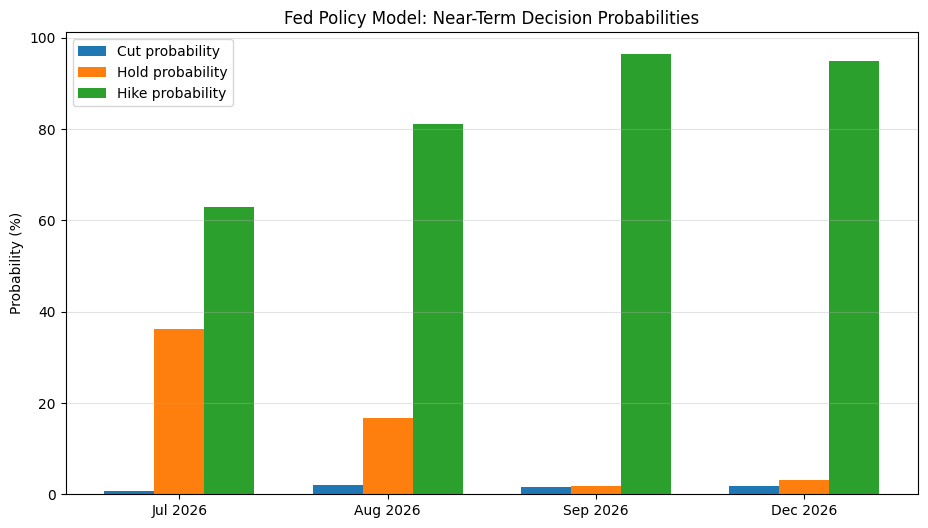

In [26]:
# ============================================================
# 11. PLOT: CURRENT POLICY PROBABILITY FORECASTS
# Single-panel chart
# ============================================================

plot_df = forecast_table.copy()

x = np.arange(len(plot_df))
width = 0.24

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    plot_df["Cut probability"],
    width,
    label="Cut probability"
)

plt.bar(
    x,
    plot_df["Hold probability"],
    width,
    label="Hold probability"
)

plt.bar(
    x + width,
    plot_df["Hike probability"],
    width,
    label="Hike probability"
)

plt.xticks(
    x,
    plot_df["Forecast end month"]
)

plt.ylabel("Probability (%)")
plt.title("Fed Policy Model: Near-Term Decision Probabilities")
plt.legend()
plt.grid(True, axis="y", alpha=0.35)
plt.show()

In [27]:
# ============================================================
# 12. FEATURE IMPORTANCE
# Logistic regression coefficient magnitude
# This shows which inputs influence model classifications most.
# ============================================================

h = 1  # examine the one-month model

clf = final_models[h]["classifier"]
logit_model = clf.named_steps["model"]

coef_df = pd.DataFrame(
    logit_model.coef_,
    columns=feature_cols,
    index=logit_model.classes_
)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Average absolute effect": coef_df.abs().mean(axis=0).values,
    "Cut effect": coef_df.loc["Cut"].values if "Cut" in coef_df.index else np.nan,
    "Hold effect": coef_df.loc["Hold"].values if "Hold" in coef_df.index else np.nan,
    "Hike effect": coef_df.loc["Hike"].values if "Hike" in coef_df.index else np.nan
}).sort_values("Average absolute effect", ascending=False)

display(importance_df.head(20))

,Feature,Average absolute effect,Cut effect,Hold effect,Hike effect
25,policy_rate_gap_2y_current,1.082,-1.487,-0.136,1.623
35,policy_rate_change_3m_bp,0.633,-0.892,-0.057,0.949
19,real_gdp_lag1,0.565,0.847,-0.473,-0.374
12,unemployment_rate_lag1,0.540,-0.214,0.809,-0.595
34,policy_rate_change_1m_bp,0.387,0.165,0.416,-0.581
29,vix_current,0.323,-0.065,0.485,-0.420
18,retail_sales_yoy_lag1,0.278,0.165,0.253,-0.417
11,brent_oil_yoy_lag1,0.269,-0.403,0.349,0.054
5,core_cpi_3m_ann_lag1,0.268,-0.282,0.402,-0.120
38,core_cpi_gap_from_2pct,0.262,-0.368,-0.026,0.394


In [28]:
display(backtest_summary)
display(forecast_table)

,Forecast horizon,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression,BP RMSE: regression,BP MAE: probability model
0,1 month(s),90,0.611,0.504,0.460,13.328,23.391,14.043
1,2 month(s),89,0.708,0.729,0.682,20.527,33.377,19.312
2,3 month(s),88,0.659,0.705,0.656,31.538,78.469,29.389
3,6 month(s),85,0.718,0.729,0.713,59.602,188.705,57.873


,Forecast origin,Horizon,Forecast end month,Cut probability,Hold probability,Hike probability,Model call,"Expected change (probability, bp)","Expected change (regression, bp)",Current upper target (%),Implied upper target (%)
0,2026-06-30,1 month(s),Jul 2026,0.700,36.300,63.000,Hike,15.600,5.300,3.750,3.910
1,2026-06-30,2 month(s),Aug 2026,2.000,16.700,81.200,Hike,19.800,12.900,3.750,3.950
2,2026-06-30,3 month(s),Sep 2026,1.700,1.900,96.400,Hike,23.700,18.900,3.750,3.990
3,2026-06-30,6 month(s),Dec 2026,1.900,3.100,95.000,Hike,23.300,43.400,3.750,3.980


## lets be sophisticated now not sober

In [29]:
# ============================================================
# COMPACT FED POLICY FEATURE SET
# One variable per economic channel
# ============================================================

compact_feature_candidates = [

    # 1. Inflation: Fed's preferred measure + recent momentum
    "core_pce_yoy_lag1",
    "core_pce_3m_ann_lag1",

    # 2. Labour market: level + deterioration signal
    "unemployment_rate_lag1",
    "unemployment_change_3m_lag1",

    # 3. Growth / domestic demand
    "retail_sales_yoy_lag1",

    # 4. Market pricing of future Fed policy
    "policy_rate_gap_2y_current",

    # 5. Financial stress / risk sentiment
    "vix_current",

    # 6. Inflation expectations
    "breakeven_5y_current",

    # 7. Policy inertia
    "policy_rate_level",
    "months_since_last_move"
]

feature_cols_compact = [
    col for col in compact_feature_candidates
    if col in model_df.columns
]

print("Compact feature count:", len(feature_cols_compact))
print(feature_cols_compact)

Compact feature count: 9
['core_pce_yoy_lag1', 'core_pce_3m_ann_lag1', 'unemployment_rate_lag1', 'unemployment_change_3m_lag1', 'retail_sales_yoy_lag1', 'policy_rate_gap_2y_current', 'vix_current', 'policy_rate_level', 'months_since_last_move']


In [30]:
feature_cols = feature_cols_compact

In [31]:
# ============================================================
# COMPACT FED POLICY MODEL
# Monthly direct forecasts:
# 1M, 2M, 3M, 6M ahead Fed target-rate changes
#
# Uses:
# - Fewer non-duplicative features
# - class_weight=None
# - Multinomial classifier: Cut / Hold / Hike
# - Ridge regression: expected cumulative bp change
# - Expanding-window backtest
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [32]:
# ============================================================
# 1. CHECK THAT model_df EXISTS
# ============================================================

if "model_df" not in globals():
    raise ValueError(
        "model_df is not available. Run the earlier feature-engineering cells first."
    )

model_df = model_df.copy().sort_index()
model_df.index = pd.to_datetime(model_df.index)

print("Model dataset period:")
print(model_df.index.min().date(), "to", model_df.index.max().date())

print("\nAvailable columns:")
print(model_df.columns.tolist())

Model dataset period:
2000-01-31 to 2026-06-30

Available columns:
['fed_target_upper', 'fed_target_lower', 'effective_fed_funds', 'headline_cpi', 'core_cpi', 'headline_pce', 'core_pce', 'unemployment_rate', 'nonfarm_payrolls', 'avg_hourly_earnings', 'initial_jobless_claims', 'industrial_production', 'retail_sales', 'real_gdp', 'treasury_3m', 'treasury_2y', 'treasury_10y', 'baa_corporate_yield', 'financial_conditions', 'breakeven_5y', 'breakeven_10y', 'inflation_expectations_1y', 'broad_dollar_index', 'brent_oil', 'sp500', 'vix', 'dxy', 'us_2y_etf_proxy', 'us_10y_etf_proxy', 'sp500_return_1d', 'sp500_return_21d', 'vix_change_5d', 'vix_change_21d', 'dxy_change_21d', 'shy_return_21d', 'ief_return_21d', 'yield_curve_10y_2y', 'yield_curve_10y_3m', 'policy_rate_gap_2y', 'fed_rate_change_bp', 'policy_changed', 'headline_cpi_yoy', 'headline_cpi_3m_ann', 'core_cpi_yoy', 'core_cpi_3m_ann', 'headline_pce_yoy', 'headline_pce_3m_ann', 'core_pce_yoy', 'core_pce_3m_ann', 'payroll_growth_3m', 'wage_g

In [33]:
# ============================================================
# 2. COMPACT FEATURE SET
# One variable per major policy channel
# ============================================================

compact_feature_candidates = [

    # Inflation: Fed-preferred inflation level and recent momentum
    "core_pce_yoy_lag1",
    "core_pce_3m_ann_lag1",

    # Labour market: current slack and recent weakening
    "unemployment_rate_lag1",
    "unemployment_change_3m_lag1",

    # Demand / growth
    "retail_sales_yoy_lag1",

    # Market-implied policy pressure
    "policy_rate_gap_2y_current",

    # Financial stress / risk sentiment
    "vix_current",

    # Inflation expectations
    "breakeven_5y_current",

    # Policy inertia
    "policy_rate_level",
    "months_since_last_move"
]

feature_cols = [
    col for col in compact_feature_candidates
    if col in model_df.columns
]

print("Compact feature count:", len(feature_cols))
print(feature_cols)

missing_compact_features = [
    col for col in compact_feature_candidates
    if col not in model_df.columns
]

if missing_compact_features:
    print("\nUnavailable variables excluded:")
    print(missing_compact_features)

Compact feature count: 9
['core_pce_yoy_lag1', 'core_pce_3m_ann_lag1', 'unemployment_rate_lag1', 'unemployment_change_3m_lag1', 'retail_sales_yoy_lag1', 'policy_rate_gap_2y_current', 'vix_current', 'policy_rate_level', 'months_since_last_move']

Unavailable variables excluded:
['breakeven_5y_current']


In [34]:
# ============================================================
# 3. CREATE FUTURE POLICY TARGETS
# ============================================================

def create_policy_targets(data, horizon_months):
    """
    Creates cumulative target-rate change over the next horizon.

    Example:
    horizon=3 means:
    Fed upper target at t+3 months minus Fed upper target at t.
    """

    out = data.copy()

    target_change_col = f"target_change_{horizon_months}m_bp"
    target_direction_col = f"target_direction_{horizon_months}m"

    out[target_change_col] = (
        out["fed_target_upper"].shift(-horizon_months)
        - out["fed_target_upper"]
    ) * 100

    out[target_direction_col] = np.select(
        [
            out[target_change_col] < 0,
            out[target_change_col] > 0
        ],
        [
            "Cut",
            "Hike"
        ],
        default="Hold"
    )

    # Future horizon unavailable at sample end: retain as NaN
    out.loc[
        out[target_change_col].isna(),
        target_direction_col
    ] = np.nan

    return out

In [39]:
# ============================================================
# 4. MODEL BUILDER
# class_weight=None: no artificial push toward rare hike/cut classes
# ============================================================

def build_classifier():

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=None,
            C=0.20,
            max_iter=5000,
            random_state=42
        ))
    ])


def build_regressor():

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-2, 5, 100)
        ))
    ])

In [40]:
# ============================================================
# 5. TRAIN FINAL MODEL FOR A GIVEN HORIZON
# ============================================================

def train_fed_policy_model(data, horizon_months, features):

    data_h = create_policy_targets(data, horizon_months).copy()

    target_change = f"target_change_{horizon_months}m_bp"
    target_direction = f"target_direction_{horizon_months}m"

    train_df = data_h.dropna(
        subset=[target_change]
    ).copy()

    X_train = train_df[features]
    y_class = train_df[target_direction]
    y_bp = train_df[target_change]

    classifier = build_classifier()
    regressor = build_regressor()

    classifier.fit(X_train, y_class)
    regressor.fit(X_train, y_bp)

    return {
        "classifier": classifier,
        "regressor": regressor,
        "train_df": train_df,
        "data_h": data_h,
        "target_change": target_change,
        "target_direction": target_direction,
        "features": features
    }

In [41]:
# ============================================================
# 6. EXPANDING-WINDOW BACKTEST
# Every forecast uses only information available up to that date.
# ============================================================

def expanding_window_backtest(
    data,
    horizon_months,
    features,
    min_train_months=120
):

    data_h = create_policy_targets(data, horizon_months).copy()

    target_change = f"target_change_{horizon_months}m_bp"
    target_direction = f"target_direction_{horizon_months}m"

    usable = data_h.dropna(
        subset=[target_change]
    ).copy()

    output_rows = []

    for i in range(min_train_months, len(usable)):

        train_part = usable.iloc[:i].copy()
        test_row = usable.iloc[[i]].copy()

        X_train = train_part[features]
        y_train_class = train_part[target_direction]
        y_train_bp = train_part[target_change]

        # Need at least two classes to estimate a classifier
        if y_train_class.nunique() < 2:
            continue

        classifier = build_classifier()
        regressor = build_regressor()

        classifier.fit(X_train, y_train_class)
        regressor.fit(X_train, y_train_bp)

        X_test = test_row[features]

        predicted_direction = classifier.predict(X_test)[0]

        probabilities = classifier.predict_proba(X_test)[0]
        classes = classifier.named_steps["model"].classes_

        probability_map = dict(zip(classes, probabilities))

        predicted_bp_regression = regressor.predict(X_test)[0]

        # Conservative expected change based on class probabilities.
        # Uses standard ±25 bp policy step.
        predicted_bp_probability = (
            probability_map.get("Cut", 0) * (-25)
            + probability_map.get("Hold", 0) * 0
            + probability_map.get("Hike", 0) * 25
        )

        output_rows.append({
            "date": test_row.index[0],
            "actual_direction": test_row[target_direction].iloc[0],
            "actual_change_bp": test_row[target_change].iloc[0],
            "predicted_direction": predicted_direction,
            "predicted_bp_regression": predicted_bp_regression,
            "predicted_bp_probability": predicted_bp_probability,
            "prob_cut": probability_map.get("Cut", 0),
            "prob_hold": probability_map.get("Hold", 0),
            "prob_hike": probability_map.get("Hike", 0)
        })

    if not output_rows:
        return pd.DataFrame()

    return pd.DataFrame(output_rows).set_index("date")

In [42]:
# ============================================================
# 7. RUN BACKTESTS: 1M, 2M, 3M, 6M
# ============================================================

HORIZONS = [1, 2, 3, 6]

backtests = {}
summary_rows = []

for h in HORIZONS:

    print(f"Running compact {h}-month model...")

    bt = expanding_window_backtest(
        data=model_df,
        horizon_months=h,
        features=feature_cols,
        min_train_months=120
    )

    backtests[h] = bt

    if bt.empty:
        print(f"No backtest available for {h}-month horizon.")
        continue

    direction_accuracy = accuracy_score(
        bt["actual_direction"],
        bt["predicted_direction"]
    )

    balanced_acc = balanced_accuracy_score(
        bt["actual_direction"],
        bt["predicted_direction"]
    )

    macro_f1 = f1_score(
        bt["actual_direction"],
        bt["predicted_direction"],
        average="macro",
        zero_division=0
    )

    mae_reg = mean_absolute_error(
        bt["actual_change_bp"],
        bt["predicted_bp_regression"]
    )

    rmse_reg = np.sqrt(
        mean_squared_error(
            bt["actual_change_bp"],
            bt["predicted_bp_regression"]
        )
    )

    mae_prob = mean_absolute_error(
        bt["actual_change_bp"],
        bt["predicted_bp_probability"]
    )

    summary_rows.append({
        "Forecast horizon": f"{h} month(s)",
        "Backtest observations": len(bt),
        "Direction accuracy": direction_accuracy,
        "Balanced accuracy": balanced_acc,
        "Macro F1": macro_f1,
        "BP MAE: regression": mae_reg,
        "BP RMSE: regression": rmse_reg,
        "BP MAE: probability model": mae_prob
    })

backtest_summary = pd.DataFrame(summary_rows)

display(backtest_summary)

Running compact 1-month model...
Running compact 2-month model...
Running compact 3-month model...
Running compact 6-month model...


,Forecast horizon,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression,BP RMSE: regression,BP MAE: probability model
0,1 month(s),90,0.778,0.466,0.464,12.617,22.145,11.343
1,2 month(s),89,0.742,0.602,0.574,19.333,29.220,19.635
2,3 month(s),88,0.659,0.596,0.565,24.440,34.494,29.821
3,6 month(s),85,0.694,0.701,0.693,38.929,52.402,60.761


In [43]:
# ============================================================
# 8. CONFUSION MATRICES
# ============================================================

for h, bt in backtests.items():

    if bt.empty:
        continue

    labels = ["Cut", "Hold", "Hike"]

    cm = confusion_matrix(
        bt["actual_direction"],
        bt["predicted_direction"],
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )

    print(f"\n{'=' * 72}")
    print(f"{h}-MONTH COMPACT MODEL: CONFUSION MATRIX")
    print(f"{'=' * 72}")

    display(cm_df)


1-MONTH COMPACT MODEL: CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,10,0
Actual: Hold,1,65,3
Actual: Hike,0,6,5



2-MONTH COMPACT MODEL: CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,1,15,0
Actual: Hold,0,50,5
Actual: Hike,2,1,15



3-MONTH COMPACT MODEL: CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,3,17,0
Actual: Hold,1,39,9
Actual: Hike,2,1,16



6-MONTH COMPACT MODEL: CONFUSION MATRIX


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,19,8,4
Actual: Hold,3,23,6
Actual: Hike,4,1,17


In [44]:
# ============================================================
# 9. TRAIN FINAL MODELS USING ALL AVAILABLE HISTORY
# ============================================================

final_models = {}

for h in HORIZONS:

    final_models[h] = train_fed_policy_model(
        data=model_df,
        horizon_months=h,
        features=feature_cols
    )

print("Final compact models trained successfully.")

Final compact models trained successfully.


In [45]:
# ============================================================
# 10. GENERATE CURRENT FORECAST
# ============================================================

# Latest monthly observation with at least some usable model data
latest_row = model_df.iloc[[-1]].copy()
forecast_origin = latest_row.index[0]

forecast_rows = []

for h in HORIZONS:

    classifier = final_models[h]["classifier"]
    regressor = final_models[h]["regressor"]

    X_latest = latest_row[feature_cols]

    predicted_direction = classifier.predict(X_latest)[0]

    probabilities = classifier.predict_proba(X_latest)[0]
    classes = classifier.named_steps["model"].classes_

    probability_map = dict(zip(classes, probabilities))

    expected_bp_probability = (
        probability_map.get("Cut", 0) * (-25)
        + probability_map.get("Hold", 0) * 0
        + probability_map.get("Hike", 0) * 25
    )

    expected_bp_regression = regressor.predict(X_latest)[0]

    current_upper_target = latest_row["fed_target_upper"].iloc[0]

    forecast_rows.append({
        "Forecast origin": forecast_origin.date(),
        "Horizon": f"{h} month(s)",
        "Forecast end month": (
            forecast_origin + pd.DateOffset(months=h)
        ).strftime("%b %Y"),
        "Cut probability": probability_map.get("Cut", 0),
        "Hold probability": probability_map.get("Hold", 0),
        "Hike probability": probability_map.get("Hike", 0),
        "Model call": predicted_direction,
        "Expected change (probability, bp)": expected_bp_probability,
        "Expected change (regression, bp)": expected_bp_regression,
        "Current upper target (%)": current_upper_target,
        "Implied upper target (%)": (
            current_upper_target + expected_bp_probability / 100
        )
    })

forecast_table = pd.DataFrame(forecast_rows)

probability_columns = [
    "Cut probability",
    "Hold probability",
    "Hike probability"
]

for col in probability_columns:
    forecast_table[col] = (
        forecast_table[col] * 100
    ).round(1)

forecast_table["Expected change (probability, bp)"] = (
    forecast_table["Expected change (probability, bp)"].round(1)
)

forecast_table["Expected change (regression, bp)"] = (
    forecast_table["Expected change (regression, bp)"].round(1)
)

forecast_table["Current upper target (%)"] = (
    forecast_table["Current upper target (%)"].round(2)
)

forecast_table["Implied upper target (%)"] = (
    forecast_table["Implied upper target (%)"].round(2)
)

display(forecast_table)

,Forecast origin,Horizon,Forecast end month,Cut probability,Hold probability,Hike probability,Model call,"Expected change (probability, bp)","Expected change (regression, bp)",Current upper target (%),Implied upper target (%)
0,2026-06-30,1 month(s),Jul 2026,1.800,73.800,24.400,Hold,5.700,12.500,3.750,3.810
1,2026-06-30,2 month(s),Aug 2026,1.900,54.000,44.100,Hold,10.600,23.600,3.750,3.860
2,2026-06-30,3 month(s),Sep 2026,2.400,35.100,62.500,Hike,15.000,31.700,3.750,3.900
3,2026-06-30,6 month(s),Dec 2026,4.100,22.700,73.100,Hike,17.200,53.500,3.750,3.920


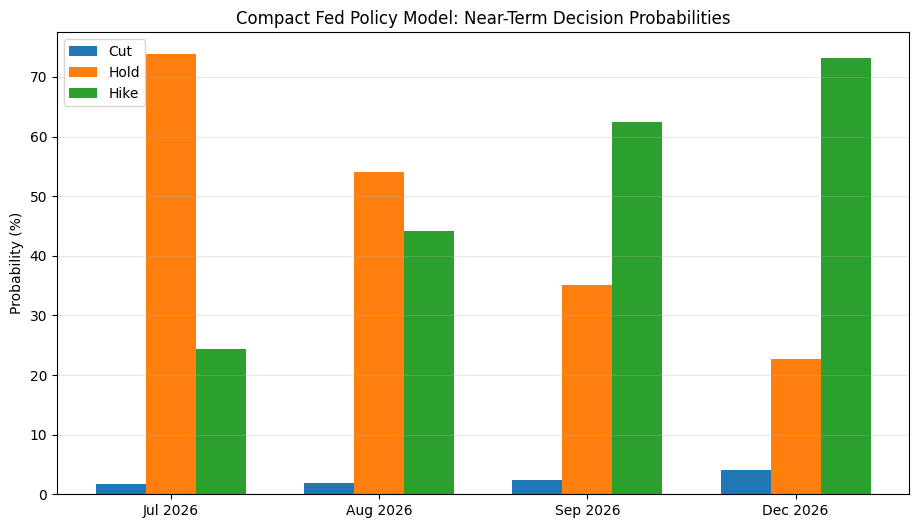

In [46]:
# ============================================================
# 11. SINGLE-PANEL CHART: FORECAST PROBABILITIES
# ============================================================

plot_df = forecast_table.copy()

x = np.arange(len(plot_df))
width = 0.24

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    plot_df["Cut probability"],
    width,
    label="Cut"
)

plt.bar(
    x,
    plot_df["Hold probability"],
    width,
    label="Hold"
)

plt.bar(
    x + width,
    plot_df["Hike probability"],
    width,
    label="Hike"
)

plt.xticks(
    x,
    plot_df["Forecast end month"]
)

plt.ylabel("Probability (%)")
plt.title("Compact Fed Policy Model: Near-Term Decision Probabilities")
plt.legend()
plt.grid(True, axis="y", alpha=0.30)

plt.show()

In [47]:
# ============================================================
# 12. FEATURE IMPORTANCE: 1-MONTH MODEL
# Absolute average logistic-regression coefficient
# ============================================================

one_month_classifier = final_models[1]["classifier"]
one_month_logit = one_month_classifier.named_steps["model"]

coef_df = pd.DataFrame(
    one_month_logit.coef_,
    columns=feature_cols,
    index=one_month_logit.classes_
)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Average absolute coefficient": coef_df.abs().mean(axis=0).values
}).sort_values(
    "Average absolute coefficient",
    ascending=False
)

display(importance_df)

,Feature,Average absolute coefficient
5,policy_rate_gap_2y_current,0.579
2,unemployment_rate_lag1,0.466
0,core_pce_yoy_lag1,0.285
6,vix_current,0.152
7,policy_rate_level,0.125
4,retail_sales_yoy_lag1,0.112
1,core_pce_3m_ann_lag1,0.077
8,months_since_last_move,0.073
3,unemployment_change_3m_lag1,0.007


In [48]:
display(backtest_summary)
display(forecast_table)

,Forecast horizon,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression,BP RMSE: regression,BP MAE: probability model
0,1 month(s),90,0.778,0.466,0.464,12.617,22.145,11.343
1,2 month(s),89,0.742,0.602,0.574,19.333,29.220,19.635
2,3 month(s),88,0.659,0.596,0.565,24.440,34.494,29.821
3,6 month(s),85,0.694,0.701,0.693,38.929,52.402,60.761


,Forecast origin,Horizon,Forecast end month,Cut probability,Hold probability,Hike probability,Model call,"Expected change (probability, bp)","Expected change (regression, bp)",Current upper target (%),Implied upper target (%)
0,2026-06-30,1 month(s),Jul 2026,1.800,73.800,24.400,Hold,5.700,12.500,3.750,3.810
1,2026-06-30,2 month(s),Aug 2026,1.900,54.000,44.100,Hold,10.600,23.600,3.750,3.860
2,2026-06-30,3 month(s),Sep 2026,2.400,35.100,62.500,Hike,15.000,31.700,3.750,3.900
3,2026-06-30,6 month(s),Dec 2026,4.100,22.700,73.100,Hike,17.200,53.500,3.750,3.920


## Meeting-level model:

### One row per FOMC meeting
### Macro data frozen at the latest release available before that meeting
### Target: cut / hold / hike at that specific meeting
### Then separately forecast cumulative changes across the July–December meeting path

In [49]:
# ============================================================
# MEETING-LEVEL FOMC POLICY MODEL
# One row = one FOMC policy decision
# ============================================================

import re
import time
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

START_YEAR = 2000
END_YEAR = 2026

In [50]:
# ============================================================
# 1. DOWNLOAD FOMC DECISION DATES
#
# Federal Reserve statements use URLs like:
# monetary20250618a.htm
#
# We scan likely meeting days only:
# Tuesday, Wednesday, Thursday, plus emergency Sunday meetings.
# ============================================================

def get_fomc_statement_dates(start_year=2000, end_year=2026):

    base_url = (
        "https://www.federalreserve.gov/newsevents/"
        "pressreleases/monetary{}a.htm"
    )

    all_dates = []

    candidate_dates = pd.date_range(
        f"{start_year}-01-01",
        f"{end_year}-12-31",
        freq="D"
    )

    # Most decision statements are Wednesday.
    # Tuesday/Thursday capture two-day meeting endings and unusual cases.
    # Sunday captures emergency meetings such as March 2020.
    candidate_dates = candidate_dates[
        candidate_dates.weekday.isin([1, 2, 3, 6])
    ]

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0"
    })

    print("Checking historical Federal Reserve policy-statement pages...")

    for i, dt in enumerate(candidate_dates):

        date_str = dt.strftime("%Y%m%d")
        url = base_url.format(date_str)

        try:
            response = session.get(url, timeout=12)

            if response.status_code == 200:

                page_text = response.text.lower()

                # Avoid unrelated monetary press releases.
                decision_keywords = [
                    "federal funds rate",
                    "federal funds target range",
                    "federal open market committee",
                    "committee decided",
                    "committee seeks to achieve"
                ]

                if any(x in page_text for x in decision_keywords):
                    all_dates.append(dt)

            # Gentle pause: avoids stressing the Fed website.
            if i % 50 == 0:
                print(f"Checked {i:,} candidate dates...")

            time.sleep(0.02)

        except Exception:
            continue

    fomc_dates = pd.DataFrame({
        "meeting_date": pd.to_datetime(sorted(set(all_dates)))
    })

    return fomc_dates


fomc_dates = get_fomc_statement_dates(
    start_year=START_YEAR,
    end_year=END_YEAR
)

print("\nFOMC decision dates found:", len(fomc_dates))
display(fomc_dates.tail(20))

Checking historical Federal Reserve policy-statement pages...
Checked 0 candidate dates...
Checked 50 candidate dates...
Checked 100 candidate dates...
Checked 150 candidate dates...
Checked 200 candidate dates...
Checked 250 candidate dates...
Checked 300 candidate dates...
Checked 350 candidate dates...
Checked 400 candidate dates...
Checked 450 candidate dates...
Checked 500 candidate dates...
Checked 550 candidate dates...
Checked 600 candidate dates...
Checked 650 candidate dates...
Checked 700 candidate dates...
Checked 750 candidate dates...
Checked 800 candidate dates...
Checked 850 candidate dates...
Checked 900 candidate dates...
Checked 950 candidate dates...
Checked 1,000 candidate dates...
Checked 1,050 candidate dates...
Checked 1,100 candidate dates...
Checked 1,150 candidate dates...
Checked 1,200 candidate dates...
Checked 1,250 candidate dates...
Checked 1,300 candidate dates...
Checked 1,350 candidate dates...
Checked 1,400 candidate dates...
Checked 1,450 candidate 

,meeting_date
725,2025-08-26
726,2025-09-17
727,2025-10-08
728,2025-10-14
729,2025-10-29
730,2025-11-19
731,2025-11-25
732,2025-12-10
733,2025-12-30
734,2026-01-06


In [51]:
# ============================================================
# 2. SAVE FOMC DATE TABLE
# You only need to download these dates once.
# ============================================================

fomc_dates.to_csv(
    f"{DATA_DIR}/fomc_decision_dates.csv",
    index=False
)

print("Saved:", f"{DATA_DIR}/fomc_decision_dates.csv")

Saved: fed_policy_data/fomc_decision_dates.csv


In [52]:
# ============================================================
# 3. PREPARE DAILY FEATURE DATA
#
# Use fed_master_daily because it contains:
# - macro data forward-filled from latest release
# - market data
# - Fed target rate
#
# Important:
# We take the feature snapshot on the day BEFORE each meeting.
# ============================================================

daily = fed_master_daily.copy().sort_index()

daily.index = pd.to_datetime(daily.index)
daily.index = daily.index.tz_localize(None) if daily.index.tz is not None else daily.index

daily = daily[~daily.index.duplicated(keep="last")].sort_index()

print("Daily data period:")
print(daily.index.min().date(), "to", daily.index.max().date())

Daily data period:
2000-01-01 to 2026-06-24


In [54]:
# ============================================================
# POLICY INERTIA: DAYS SINCE LAST RATE MOVE
# ============================================================

meeting_feature_daily["fed_rate_change_bp"] = (
    meeting_feature_daily["fed_target_upper"].diff() * 100
)

# Create a datetime Series: date appears only on actual policy-change days
last_move_date = pd.Series(
    pd.NaT,
    index=meeting_feature_daily.index,
    dtype="datetime64[ns]"
)

move_mask = (
    meeting_feature_daily["fed_rate_change_bp"]
    .fillna(0)
    .ne(0)
)

last_move_date.loc[move_mask] = meeting_feature_daily.index[move_mask]

# Carry last known policy-move date forward
last_move_date = last_move_date.ffill()

# Difference in calendar days
meeting_feature_daily["days_since_last_rate_move"] = (
    pd.Series(meeting_feature_daily.index, index=meeting_feature_daily.index)
    - last_move_date
).dt.days

display(
    meeting_feature_daily[
        [
            "fed_target_upper",
            "fed_rate_change_bp",
            "days_since_last_rate_move"
        ]
    ].tail(20)
)

,fed_target_upper,fed_rate_change_bp,days_since_last_rate_move
date,,,
2026-06-05,3.750,0.000,176.000
2026-06-06,3.750,0.000,177.000
2026-06-07,3.750,0.000,178.000
2026-06-08,3.750,0.000,179.000
2026-06-09,3.750,0.000,180.000
2026-06-10,3.750,0.000,181.000
2026-06-11,3.750,0.000,182.000
2026-06-12,3.750,0.000,183.000
2026-06-13,3.750,0.000,184.000


In [57]:
# ============================================================
# 4. CREATE DAILY POLICY FEATURES
# ============================================================

meeting_feature_daily = daily.copy()

# Inflation: use year-on-year and short-run momentum
for col in ["core_pce", "headline_pce", "core_cpi", "headline_cpi"]:
    if col in meeting_feature_daily.columns:
        meeting_feature_daily[f"{col}_yoy"] = (
            meeting_feature_daily[col].pct_change(252) * 100
        )

# Monthly measures need 63 business days approx. for 3 months.
if "core_pce" in meeting_feature_daily.columns:
    meeting_feature_daily["core_pce_3m_ann"] = (
        (
            meeting_feature_daily["core_pce"]
            / meeting_feature_daily["core_pce"].shift(63)
        ) ** 4 - 1
    ) * 100

# Labour-market deterioration
if "unemployment_rate" in meeting_feature_daily.columns:
    meeting_feature_daily["unemployment_change_3m"] = (
        meeting_feature_daily["unemployment_rate"]
        - meeting_feature_daily["unemployment_rate"].shift(63)
    )

# Payroll growth over approx. three months
if "nonfarm_payrolls" in meeting_feature_daily.columns:
    meeting_feature_daily["payroll_growth_3m"] = (
        meeting_feature_daily["nonfarm_payrolls"]
        .pct_change(63) * 100
    )

# Retail demand growth
if "retail_sales" in meeting_feature_daily.columns:
    meeting_feature_daily["retail_sales_yoy"] = (
        meeting_feature_daily["retail_sales"]
        .pct_change(252) * 100
    )

# Market-policy gap
if {"treasury_2y", "fed_target_upper"}.issubset(meeting_feature_daily.columns):
    meeting_feature_daily["policy_rate_gap_2y"] = (
        meeting_feature_daily["treasury_2y"]
        - meeting_feature_daily["fed_target_upper"]
    )

# Yield curve
if {"treasury_10y", "treasury_2y"}.issubset(meeting_feature_daily.columns):
    meeting_feature_daily["yield_curve_10y_2y"] = (
        meeting_feature_daily["treasury_10y"]
        - meeting_feature_daily["treasury_2y"]
    )

# Equity and VIX recent movements
if "sp500" in meeting_feature_daily.columns:
    meeting_feature_daily["sp500_return_21d"] = (
        meeting_feature_daily["sp500"]
        .pct_change(21) * 100
    )

if "vix" in meeting_feature_daily.columns:
    meeting_feature_daily["vix_change_21d"] = (
        meeting_feature_daily["vix"]
        .pct_change(21) * 100
    )
# ============================================================
# POLICY INERTIA: DAYS SINCE LAST RATE MOVE
# ============================================================

meeting_feature_daily["fed_rate_change_bp"] = (
    meeting_feature_daily["fed_target_upper"].diff() * 100
)

# Create a datetime Series: date appears only on actual policy-change days
last_move_date = pd.Series(
    pd.NaT,
    index=meeting_feature_daily.index,
    dtype="datetime64[ns]"
)

move_mask = (
    meeting_feature_daily["fed_rate_change_bp"]
    .fillna(0)
    .ne(0)
)

last_move_date.loc[move_mask] = meeting_feature_daily.index[move_mask]

# Carry last known policy-move date forward
last_move_date = last_move_date.ffill()

# Difference in calendar days
meeting_feature_daily["days_since_last_rate_move"] = (
    pd.Series(meeting_feature_daily.index, index=meeting_feature_daily.index)
    - last_move_date
).dt.days

display(
    meeting_feature_daily[
        [
            "fed_target_upper",
            "fed_rate_change_bp",
            "days_since_last_rate_move"
        ]
    ].tail(20)
)


display(meeting_feature_daily.tail())

,fed_target_upper,fed_rate_change_bp,days_since_last_rate_move
date,,,
2026-06-05,3.750,0.000,176.000
2026-06-06,3.750,0.000,177.000
2026-06-07,3.750,0.000,178.000
2026-06-08,3.750,0.000,179.000
2026-06-09,3.750,0.000,180.000
2026-06-10,3.750,0.000,181.000
2026-06-11,3.750,0.000,182.000
2026-06-12,3.750,0.000,183.000
2026-06-13,3.750,0.000,184.000


,fed_target_upper,fed_target_lower,effective_fed_funds,headline_cpi,core_cpi,headline_pce,core_pce,unemployment_rate,nonfarm_payrolls,avg_hourly_earnings,initial_jobless_claims,industrial_production,retail_sales,real_gdp,treasury_3m,treasury_2y,treasury_10y,baa_corporate_yield,financial_conditions,breakeven_5y,breakeven_10y,inflation_expectations_1y,broad_dollar_index,brent_oil,sp500,vix,dxy,us_2y_etf_proxy,us_10y_etf_proxy,sp500_return_1d,sp500_return_21d,vix_change_5d,vix_change_21d,dxy_change_21d,shy_return_21d,ief_return_21d,yield_curve_10y_2y,yield_curve_10y_3m,policy_rate_gap_2y,fed_rate_change_bp,policy_changed,core_pce_yoy,headline_pce_yoy,core_cpi_yoy,headline_cpi_yoy,core_pce_3m_ann,unemployment_change_3m,payroll_growth_3m,retail_sales_yoy,days_since_last_rate_move
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-20,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.190,4.460,6.100,-0.505,2.270,2.250,3.019,120.396,84.360,"7,500.580",16.400,100.850,81.990,94.360,1.085,-1.049,-15.638,7.050,1.756,0.101,1.000,0.270,0.860,0.440,0.000,0,1.876,2.370,1.726,3.002,0.000,0.000,0.108,4.467,191.000
2026-06-21,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.190,4.460,6.100,-0.505,2.270,2.250,3.019,120.396,84.360,"7,500.580",16.400,100.850,81.990,94.360,1.085,-1.049,-15.638,7.050,1.756,0.101,1.000,0.270,0.860,0.440,0.000,0,1.876,2.370,1.726,3.002,0.000,0.000,0.108,4.467,192.000
2026-06-22,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.240,4.510,6.100,-0.505,2.280,2.230,3.019,120.396,84.360,"7,472.790",17.280,101.020,81.910,94.000,-0.371,-1.673,-2.262,7.664,1.845,0.015,0.550,0.270,0.910,0.490,0.000,0,1.876,2.370,1.726,3.002,0.000,0.000,0.108,4.467,193.000
2026-06-23,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.240,4.510,6.100,-0.505,2.240,2.210,3.019,120.396,84.360,"7,365.460",19.490,101.410,81.970,94.120,-1.436,-3.211,20.309,23.589,2.104,0.113,0.593,0.270,0.910,0.490,0.000,0,1.876,2.370,1.726,3.002,0.000,0.000,0.108,4.467,194.000
2026-06-24,3.750,3.500,3.630,333.979,336.121,130.902,129.630,4.300,"159,001.000",37.530,"226,000.000",102.647,"763,705.000","24,152.656",3.600,4.240,4.510,6.100,-0.505,2.240,2.210,3.019,120.396,84.360,"7,365.460",19.490,101.410,81.970,94.120,-1.436,-2.492,20.309,21.357,2.104,0.113,0.593,0.270,0.910,0.490,0.000,0,1.876,2.370,1.726,3.002,0.000,0.000,0.108,4.467,195.000


In [58]:
# ============================================================
# 5. COMPACT MEETING-LEVEL FEATURE SET
# One representative variable per policy channel.
# ============================================================

meeting_feature_candidates = [

    # Inflation
    "core_pce_yoy",
    "core_pce_3m_ann",

    # Labour market
    "unemployment_rate",
    "unemployment_change_3m",

    # Demand
    "retail_sales_yoy",

    # Market pricing
    "policy_rate_gap_2y",

    # Inflation expectations
    "breakeven_5y",

    # Financial stress
    "vix",

    # Policy inertia
    "fed_target_upper",
    "days_since_last_rate_move"
]

meeting_features = [
    col for col in meeting_feature_candidates
    if col in meeting_feature_daily.columns
]

print("Meeting-level features:", len(meeting_features))
print(meeting_features)

Meeting-level features: 10
['core_pce_yoy', 'core_pce_3m_ann', 'unemployment_rate', 'unemployment_change_3m', 'retail_sales_yoy', 'policy_rate_gap_2y', 'breakeven_5y', 'vix', 'fed_target_upper', 'days_since_last_rate_move']


In [59]:
# ============================================================
# 6. CREATE ONE ROW PER FOMC MEETING
#
# Features are frozen on the business day immediately before
# the FOMC decision.
# ============================================================

def get_previous_available_date(index, meeting_date):

    available_dates = index[index < meeting_date]

    if len(available_dates) == 0:
        return pd.NaT

    return available_dates[-1]


meeting_rows = []

for meeting_date in fomc_dates["meeting_date"]:

    snapshot_date = get_previous_available_date(
        meeting_feature_daily.index,
        meeting_date
    )

    if pd.isna(snapshot_date):
        continue

    if meeting_date not in meeting_feature_daily.index:
        continue

    row = meeting_feature_daily.loc[snapshot_date, meeting_features].copy()

    # Rate before decision = snapshot date target.
    rate_before = meeting_feature_daily.loc[
        snapshot_date,
        "fed_target_upper"
    ]

    # Rate after decision = meeting-date target.
    rate_after = meeting_feature_daily.loc[
        meeting_date,
        "fed_target_upper"
    ]

    decision_change_bp = (rate_after - rate_before) * 100

    if decision_change_bp < 0:
        decision = "Cut"
    elif decision_change_bp > 0:
        decision = "Hike"
    else:
        decision = "Hold"

    row["meeting_date"] = meeting_date
    row["snapshot_date"] = snapshot_date
    row["rate_before"] = rate_before
    row["rate_after"] = rate_after
    row["decision_change_bp"] = decision_change_bp
    row["decision"] = decision

    meeting_rows.append(row)

meeting_df = pd.DataFrame(meeting_rows)

meeting_df = (
    meeting_df
    .set_index("meeting_date")
    .sort_index()
)

print("Meeting-level observations:", len(meeting_df))
display(meeting_df.tail(20))

Meeting-level observations: 745


,core_pce_yoy,core_pce_3m_ann,unemployment_rate,unemployment_change_3m,retail_sales_yoy,policy_rate_gap_2y,breakeven_5y,vix,fed_target_upper,days_since_last_rate_move,snapshot_date,rate_before,rate_after,decision_change_bp,decision
meeting_date,,,,,,,,,,,,,,,
2025-08-26,2.027,1.894,4.300,0.200,2.013,-0.770,2.490,14.790,4.500,249.000,2025-08-25,4.500,4.500,0.000,Hold
2025-09-17,1.900,1.668,4.400,0.100,2.943,-0.990,2.420,16.360,4.500,271.000,2025-09-16,4.500,4.500,0.000,Hold
2025-10-08,2.132,1.680,4.400,0.100,2.783,-0.680,2.390,17.240,4.250,19.000,2025-10-07,4.250,4.250,0.000,Hold
2025-10-14,1.676,1.680,4.400,0.100,2.737,-0.730,2.350,19.030,4.250,25.000,2025-10-13,4.250,4.250,0.000,Hold
2025-10-29,1.676,1.680,4.400,0.100,2.737,-0.780,2.360,16.420,4.250,40.000,2025-10-28,4.250,4.250,0.000,Hold
2025-11-19,1.758,1.633,4.500,0.100,1.573,-0.420,2.360,24.690,4.000,19.000,2025-11-18,4.000,4.000,0.000,Hold
2025-11-25,1.758,1.633,4.500,0.100,1.573,-0.540,2.300,20.520,4.000,25.000,2025-11-24,4.000,4.000,0.000,Hold
2025-12-10,1.900,2.037,4.400,0.000,1.699,-0.390,2.320,16.930,4.000,40.000,2025-12-09,4.000,4.000,0.000,Hold
2025-12-30,1.900,2.037,4.400,0.000,1.699,-0.300,2.230,14.200,3.750,18.000,2025-12-29,3.750,3.750,0.000,Hold


In [60]:
# ============================================================
# 7. CHECK TARGET DISTRIBUTION
# ============================================================

decision_distribution = (
    meeting_df["decision"]
    .value_counts()
    .reindex(["Cut", "Hold", "Hike"], fill_value=0)
    .to_frame("Number of meetings")
)

decision_distribution["Share (%)"] = (
    decision_distribution["Number of meetings"]
    / decision_distribution["Number of meetings"].sum()
    * 100
).round(1)

display(decision_distribution)

,Number of meetings,Share (%)
decision,,
Cut,4,0.500
Hold,728,97.700
Hike,13,1.700


In [63]:
# ============================================================
# 8. TRAINING FUNCTIONS
# class_weight=None
# ============================================================

def build_meeting_classifier():

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=None,
            C=0.15,
            max_iter=5000,
            random_state=42
        ))
    ])


def build_meeting_regressor():

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-2, 5, 100)
        ))
    ])

In [69]:
# ============================================================
# 9. EXPANDING-WINDOW MEETING-LEVEL BACKTEST
# ============================================================

def meeting_level_backtest(
    data,
    features,
    min_train_meetings=50
):
    """
    Expanding-window FOMC meeting-level backtest.

    One row = one FOMC decision.
    Features are frozen before the meeting.
    Target is the actual decision at that meeting.
    """

    # --------------------------------------------------------
    # Clean dataset and target variables
    # --------------------------------------------------------
    data = data.copy()

    data["decision_change_bp"] = pd.to_numeric(
        data["decision_change_bp"],
        errors="coerce"
    )

    # Remove rows where actual policy target is unavailable
    data = data.dropna(
        subset=["decision_change_bp", "decision"]
    ).copy()

    # Keep chronological order
    data = data.sort_index()

    output_rows = []

    # --------------------------------------------------------
    # Expanding-window estimation
    # --------------------------------------------------------
    for i in range(min_train_meetings, len(data)):

        train_part = data.iloc[:i].copy()
        test_row = data.iloc[[i]].copy()

        X_train = train_part[features]
        y_train_class = train_part["decision"]
        y_train_bp = train_part["decision_change_bp"]

        # Skip early windows that do not yet contain at least
        # two possible decision classes.
        if y_train_class.nunique() < 2:
            continue

        classifier = build_meeting_classifier()
        regressor = build_meeting_regressor()

        classifier.fit(X_train, y_train_class)
        regressor.fit(X_train, y_train_bp)

        X_test = test_row[features]

        # ----------------------------------------------------
        # Classifier prediction
        # ----------------------------------------------------
        predicted_decision = classifier.predict(X_test)[0]

        probabilities = classifier.predict_proba(X_test)[0]
        classes = classifier.named_steps["model"].classes_

        probability_map = dict(zip(classes, probabilities))

        # ----------------------------------------------------
        # Regression prediction
        # ----------------------------------------------------
        predicted_bp_regression = regressor.predict(X_test)[0]

        # Probability-implied expected move.
        # Uses standard meeting steps of ±25 bp.
        predicted_bp_probability = (
            probability_map.get("Cut", 0) * (-25)
            + probability_map.get("Hold", 0) * 0
            + probability_map.get("Hike", 0) * 25
        )

        output_rows.append({
            "meeting_date": test_row.index[0],
            "actual_decision": test_row["decision"].iloc[0],
            "actual_change_bp": test_row["decision_change_bp"].iloc[0],
            "predicted_decision": predicted_decision,
            "predicted_bp_regression": predicted_bp_regression,
            "predicted_bp_probability": predicted_bp_probability,
            "prob_cut": probability_map.get("Cut", 0),
            "prob_hold": probability_map.get("Hold", 0),
            "prob_hike": probability_map.get("Hike", 0)
        })

    # Avoid error if no valid expanding-window forecasts were produced
    if len(output_rows) == 0:
        print("No backtest forecasts were generated.")
        return pd.DataFrame()

    return (
        pd.DataFrame(output_rows)
        .set_index("meeting_date")
        .sort_index()
    )


# ============================================================
# RUN MEETING-LEVEL BACKTEST
# ============================================================

meeting_backtest = meeting_level_backtest(
    data=meeting_df,
    features=meeting_features,
    min_train_meetings=50
)

print("Backtest observations:", len(meeting_backtest))

display(meeting_backtest.tail(20))

Backtest observations: 316


,actual_decision,actual_change_bp,predicted_decision,predicted_bp_regression,predicted_bp_probability,prob_cut,prob_hold,prob_hike
meeting_date,,,,,,,,
2025-08-26,Hold,0.000,Hold,-0.749,-0.100,0.012,0.981,0.008
2025-09-17,Hold,0.000,Hold,-1.686,-0.245,0.015,0.980,0.005
2025-10-08,Hold,0.000,Hold,-0.284,-0.101,0.009,0.987,0.005
2025-10-14,Hold,0.000,Hold,-0.696,-0.165,0.011,0.984,0.005
2025-10-29,Hold,0.000,Hold,-0.868,-0.180,0.012,0.983,0.005
2025-11-19,Hold,0.000,Hold,0.262,-0.025,0.008,0.985,0.007
2025-11-25,Hold,0.000,Hold,-0.153,-0.078,0.009,0.985,0.006
2025-12-10,Hold,0.000,Hold,0.586,0.035,0.007,0.984,0.009
2025-12-30,Hold,0.000,Hold,0.823,0.078,0.007,0.983,0.010


In [70]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

labels = ["Cut", "Hold", "Hike"]

cm = confusion_matrix(
    meeting_backtest["actual_decision"],
    meeting_backtest["predicted_decision"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {x}" for x in labels],
    columns=[f"Predicted: {x}" for x in labels]
)

display(cm_df)

,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,4,0
Actual: Hold,1,299,0
Actual: Hike,0,12,0


In [71]:
# ============================================================
# 12. TRAIN FINAL MODEL ON CLEAN MEETING-LEVEL HISTORY
# ============================================================

# Keep only rows with a valid numeric policy decision target
meeting_train_df = meeting_df.copy()

meeting_train_df["decision_change_bp"] = pd.to_numeric(
    meeting_train_df["decision_change_bp"],
    errors="coerce"
)

meeting_train_df = meeting_train_df.dropna(
    subset=["decision_change_bp", "decision"]
).copy()

# Also remove rows where all model features are missing
meeting_train_df = meeting_train_df.dropna(
    subset=meeting_features,
    how="all"
).copy()

print("Original meeting rows:", len(meeting_df))
print("Usable training rows:", len(meeting_train_df))

print("\nMissing target rows removed:")
display(
    meeting_df.loc[
        meeting_df["decision_change_bp"].isna(),
        ["snapshot_date", "rate_before", "rate_after",
         "decision_change_bp", "decision"]
    ]
)

print("\nTraining target distribution:")
display(
    meeting_train_df["decision"]
    .value_counts()
    .reindex(["Cut", "Hold", "Hike"], fill_value=0)
)

# Train final models
final_meeting_classifier = build_meeting_classifier()
final_meeting_regressor = build_meeting_regressor()

X_final = meeting_train_df[meeting_features]
y_final_class = meeting_train_df["decision"]
y_final_bp = meeting_train_df["decision_change_bp"]

final_meeting_classifier.fit(X_final, y_final_class)
final_meeting_regressor.fit(X_final, y_final_bp)

print("\nFinal meeting-level classifier and regression model trained.")

Original meeting rows: 745
Usable training rows: 625

Missing target rows removed:


,snapshot_date,rate_before,rate_after,decision_change_bp,decision
meeting_date,,,,,
2006-01-03,2006-01-02,NaN,NaN,NaN,Hold
2006-01-10,2006-01-09,NaN,NaN,NaN,Hold
2006-01-31,2006-01-30,NaN,NaN,NaN,Hold
2006-02-08,2006-02-07,NaN,NaN,NaN,Hold
2006-02-21,2006-02-20,NaN,NaN,NaN,Hold
...,...,...,...,...,...
2008-11-20,2008-11-19,NaN,NaN,NaN,Hold
2008-11-25,2008-11-24,NaN,NaN,NaN,Hold
2008-12-02,2008-12-01,NaN,NaN,NaN,Hold



Training target distribution:


decision
Cut       4
Hold    608
Hike     13
Name: count, dtype: int64


Final meeting-level classifier and regression model trained.


In [73]:
# ============================================================
# 13. UPCOMING FOMC MEETING DATES
# Update this list each year from the official FOMC calendar.
# ============================================================

upcoming_fomc_dates = pd.to_datetime([
    "2026-07-29",
    "2026-09-16",
    "2026-10-28",
    "2026-12-09"
])

upcoming_fomc_dates

DatetimeIndex(['2026-07-29', '2026-09-16', '2026-10-28', '2026-12-09'], dtype='datetime64[ns]', freq=None)

In [75]:
# ============================================================
# 13. MEETING-LEVEL BACKTEST METRICS
# ============================================================

if meeting_backtest.empty:
    print("Meeting backtest is empty. Check the minimum training size.")
else:
    meeting_summary = pd.DataFrame([{
        "Backtest meetings": len(meeting_backtest),

        "Direction accuracy": accuracy_score(
            meeting_backtest["actual_decision"],
            meeting_backtest["predicted_decision"]
        ),

        "Balanced accuracy": balanced_accuracy_score(
            meeting_backtest["actual_decision"],
            meeting_backtest["predicted_decision"]
        ),

        "Macro F1": f1_score(
            meeting_backtest["actual_decision"],
            meeting_backtest["predicted_decision"],
            average="macro",
            zero_division=0
        ),

        "BP MAE: regression": mean_absolute_error(
            meeting_backtest["actual_change_bp"],
            meeting_backtest["predicted_bp_regression"]
        ),

        "BP RMSE: regression": np.sqrt(
            mean_squared_error(
                meeting_backtest["actual_change_bp"],
                meeting_backtest["predicted_bp_regression"]
            )
        ),

        "BP MAE: probability model": mean_absolute_error(
            meeting_backtest["actual_change_bp"],
            meeting_backtest["predicted_bp_probability"]
        )
    }])

    display(meeting_summary)

,Backtest meetings,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression,BP RMSE: regression,BP MAE: probability model
0,316,0.946,0.332,0.324,3.050,8.982,2.585


In [76]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

if not meeting_backtest.empty:

    labels = ["Cut", "Hold", "Hike"]

    cm = confusion_matrix(
        meeting_backtest["actual_decision"],
        meeting_backtest["predicted_decision"],
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )

    display(cm_df)

,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,4,0
Actual: Hold,1,299,0
Actual: Hike,0,12,0


In [77]:
# ============================================================
# 15. FEATURE IMPORTANCE
# Logistic-regression coefficients after standardisation
# ============================================================

logit_model = final_meeting_classifier.named_steps["model"]

coef_df = pd.DataFrame(
    logit_model.coef_,
    columns=meeting_features,
    index=logit_model.classes_
)

meeting_importance = pd.DataFrame({
    "Feature": meeting_features,
    "Average absolute coefficient": coef_df.abs().mean(axis=0).values
})

for decision_class in logit_model.classes_:
    meeting_importance[f"{decision_class} coefficient"] = (
        coef_df.loc[decision_class].values
    )

meeting_importance = meeting_importance.sort_values(
    "Average absolute coefficient",
    ascending=False
)

display(meeting_importance)

,Feature,Average absolute coefficient,Cut coefficient,Hike coefficient,Hold coefficient
5,policy_rate_gap_2y,0.569,-0.611,0.854,-0.243
2,unemployment_rate,0.445,-0.269,-0.399,0.668
0,core_pce_yoy,0.192,-0.228,-0.059,0.287
8,fed_target_upper,0.165,0.015,0.233,-0.248
6,breakeven_5y,0.137,-0.172,-0.034,0.206
7,vix,0.110,-0.020,-0.145,0.165
9,days_since_last_rate_move,0.108,-0.036,0.162,-0.126
1,core_pce_3m_ann,0.081,-0.121,0.043,0.078
4,retail_sales_yoy,0.052,-0.078,0.057,0.021
3,unemployment_change_3m,0.036,0.053,-0.027,-0.027


In [78]:
# ============================================================
# 16. UPCOMING FOMC DATES
# ============================================================

upcoming_fomc_dates = pd.to_datetime([
    "2026-07-29",
    "2026-09-16",
    "2026-10-28",
    "2026-12-09"
])

upcoming_fomc_dates

DatetimeIndex(['2026-07-29', '2026-09-16', '2026-10-28', '2026-12-09'], dtype='datetime64[ns]', freq=None)

In [79]:
# ============================================================
# 17. CREATE CURRENT-INFORMATION FEATURE SNAPSHOT
#
# For every future meeting, this uses the latest available
# macro-market information as of today.
# Later, before each meeting, rerun this notebook to update it.
# ============================================================

meeting_feature_daily = meeting_feature_daily.copy().sort_index()

last_available_date = meeting_feature_daily.index.max()

print("Last available feature date:", last_available_date.date())

latest_feature_row = pd.DataFrame(
    [meeting_feature_daily.loc[last_available_date, meeting_features]],
    columns=meeting_features
)

display(latest_feature_row)

Last available feature date: 2026-06-24


,core_pce_yoy,core_pce_3m_ann,unemployment_rate,unemployment_change_3m,retail_sales_yoy,policy_rate_gap_2y,breakeven_5y,vix,fed_target_upper,days_since_last_rate_move
2026-06-24,1.876,0.000,4.300,0.000,4.467,0.490,2.240,19.490,3.750,195.000


## Seems new issues : Move vs Hold,

In [82]:
# ============================================================
# MEETING-LEVEL FOMC MODEL — CLEAN VERSION
#
# Main meeting model:
#   Move vs Hold
#
# Conditional direction:
#   Use monthly compact model separately for Cut vs Hike bias
#
# One row = one actual FOMC meeting
# Features = latest available information before that meeting
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    brier_score_loss
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

FOMC_DATE_FILE = f"{DATA_DIR}/fomc_meeting_dates_official.csv"

CURRENT_FORECAST_DATE = pd.Timestamp("2026-06-30")

# Use a compact model because true policy moves are rare.
MIN_TRAIN_MEETINGS = 50

## Monthly Compact Model — Random Forest & Ensemble Robustness

In [84]:

# ============================================================
# MONTHLY COMPACT MODEL: RF + ENSEMBLE ROBUSTNESS
# Keeps the same compact features and horizons as the logistic/
# ridge benchmark. All models are evaluated with identical
# expanding-window forecasts.
# ============================================================

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import log_loss, brier_score_loss

# Fixed class order makes probability comparison stable even when
# an early training window has not observed every class.
POLICY_CLASSES = np.array(["Cut", "Hold", "Hike"])

# Ensemble weights: benchmark remains important because the
# monthly sample is modest; RF captures nonlinear interactions.
W_LOGIT = 0.50
W_RF = 0.50

print("Feature count:", len(feature_cols))
print("Features:", feature_cols)


Feature count: 9
Features: ['core_pce_yoy_lag1', 'core_pce_3m_ann_lag1', 'unemployment_rate_lag1', 'unemployment_change_3m_lag1', 'retail_sales_yoy_lag1', 'policy_rate_gap_2y_current', 'vix_current', 'policy_rate_level', 'months_since_last_move']


In [88]:

# ============================================================
# 1. MODEL BUILDERS
# ============================================================

def build_logit_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight=None,
            C=0.20,
            max_iter=5000,
            random_state=42
        ))
    ])


def build_ridge_regressor():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-2, 5, 100)
        ))
    ])


def build_rf_classifier():
    """
    Conservative RF specification for a small monthly sample.
    Shallower trees and a larger minimum leaf reduce overfitting.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=3,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight=None,
            random_state=42,
            n_jobs=-1
        ))
    ])


def build_rf_regressor():
    """
    Conservative RF regressor for cumulative bp changes.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=3,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ])


def aligned_probabilities(model, X, class_order=POLICY_CLASSES):
    """
    Returns probabilities in fixed Cut/Hold/Hike order, even when
    the model was trained before one class appeared in history.
    """
    raw_probs = model.predict_proba(X)[0]

    # Pipeline final step always exposes classes_.
    if hasattr(model, "named_steps"):
        final_estimator = list(model.named_steps.values())[-1]
        observed_classes = final_estimator.classes_
    else:
        observed_classes = model.classes_

    out = np.zeros(len(class_order), dtype=float)

    for cls, prob in zip(observed_classes, raw_probs):
        loc = np.where(class_order == cls)[0]
        if len(loc) == 1:
            out[loc[0]] = prob

    return out


In [89]:

# ============================================================
# 2. EXPANDING-WINDOW BACKTEST:
# LOGIT/RIDGE vs RANDOM FOREST vs 50:50 ENSEMBLE
# ============================================================

def expanding_window_rf_ensemble_backtest(
    data,
    horizon_months,
    features,
    min_train_months=120
):
    data_h = create_policy_targets(data, horizon_months).copy()

    target_change = f"target_change_{horizon_months}m_bp"
    target_direction = f"target_direction_{horizon_months}m"

    usable = data_h.dropna(subset=[target_change, target_direction]).copy()
    usable = usable.sort_index()

    output_rows = []

    for i in range(min_train_months, len(usable)):

        train_part = usable.iloc[:i].copy()
        test_row = usable.iloc[[i]].copy()

        X_train = train_part[features]
        y_class = train_part[target_direction]
        y_bp = train_part[target_change]
        X_test = test_row[features]

        # A classifier needs at least two classes in the historical window.
        if y_class.nunique() < 2:
            continue

        logit = build_logit_classifier()
        rf_clf = build_rf_classifier()
        ridge = build_ridge_regressor()
        rf_reg = build_rf_regressor()

        logit.fit(X_train, y_class)
        rf_clf.fit(X_train, y_class)
        ridge.fit(X_train, y_bp)
        rf_reg.fit(X_train, y_bp)

        p_logit = aligned_probabilities(logit, X_test)
        p_rf = aligned_probabilities(rf_clf, X_test)
        p_ens = W_LOGIT * p_logit + W_RF * p_rf

        logit_call = POLICY_CLASSES[np.argmax(p_logit)]
        rf_call = POLICY_CLASSES[np.argmax(p_rf)]
        ens_call = POLICY_CLASSES[np.argmax(p_ens)]

        bp_ridge = float(ridge.predict(X_test)[0])
        bp_rf = float(rf_reg.predict(X_test)[0])
        bp_ens = W_LOGIT * bp_ridge + W_RF * bp_rf

        # Probability-implied expected move uses standard ±25 bp steps.
        prob_bp_logit = float(np.dot(p_logit, [-25, 0, 25]))
        prob_bp_rf = float(np.dot(p_rf, [-25, 0, 25]))
        prob_bp_ens = float(np.dot(p_ens, [-25, 0, 25]))

        output_rows.append({
            "date": test_row.index[0],
            "actual_direction": test_row[target_direction].iloc[0],
            "actual_change_bp": float(test_row[target_change].iloc[0]),

            "logit_call": logit_call,
            "rf_call": rf_call,
            "ensemble_call": ens_call,

            "logit_prob_cut": p_logit[0],
            "logit_prob_hold": p_logit[1],
            "logit_prob_hike": p_logit[2],

            "rf_prob_cut": p_rf[0],
            "rf_prob_hold": p_rf[1],
            "rf_prob_hike": p_rf[2],

            "ensemble_prob_cut": p_ens[0],
            "ensemble_prob_hold": p_ens[1],
            "ensemble_prob_hike": p_ens[2],

            "bp_ridge": bp_ridge,
            "bp_rf": bp_rf,
            "bp_ensemble": bp_ens,

            "bp_prob_logit": prob_bp_logit,
            "bp_prob_rf": prob_bp_rf,
            "bp_prob_ensemble": prob_bp_ens
        })

    if not output_rows:
        return pd.DataFrame()

    return pd.DataFrame(output_rows).set_index("date").sort_index()


In [90]:

# ============================================================
# 3. RUN ROBUSTNESS BACKTESTS FOR ALL MONTHLY HORIZONS
# ============================================================

HORIZONS = [1, 2, 3, 6]

rf_ensemble_backtests = {}
robustness_rows = []

for h in HORIZONS:

    print(f"Running {h}-month RF / ensemble backtest...")

    bt = expanding_window_rf_ensemble_backtest(
        data=model_df,
        horizon_months=h,
        features=feature_cols,
        min_train_months=120
    )

    rf_ensemble_backtests[h] = bt

    if bt.empty:
        print(f"No usable backtest observations for {h}M.")
        continue

    for model_name, call_col, bp_col, prob_bp_col in [
        ("Logit + Ridge benchmark", "logit_call", "bp_ridge", "bp_prob_logit"),
        ("Random Forest", "rf_call", "bp_rf", "bp_prob_rf"),
        ("50:50 Ensemble", "ensemble_call", "bp_ensemble", "bp_prob_ensemble")
    ]:
        robustness_rows.append({
            "Forecast horizon": f"{h} month(s)",
            "Model": model_name,
            "Backtest observations": len(bt),
            "Direction accuracy": accuracy_score(
                bt["actual_direction"], bt[call_col]
            ),
            "Balanced accuracy": balanced_accuracy_score(
                bt["actual_direction"], bt[call_col]
            ),
            "Macro F1": f1_score(
                bt["actual_direction"], bt[call_col],
                average="macro", zero_division=0
            ),
            "BP MAE: regression / ensemble": mean_absolute_error(
                bt["actual_change_bp"], bt[bp_col]
            ),
            "BP RMSE: regression / ensemble": np.sqrt(
                mean_squared_error(bt["actual_change_bp"], bt[bp_col])
            ),
            "BP MAE: probability model": mean_absolute_error(
                bt["actual_change_bp"], bt[prob_bp_col]
            )
        })

robustness_summary = pd.DataFrame(robustness_rows)

display(
    robustness_summary.sort_values(
        ["Forecast horizon", "Model"]
    ).reset_index(drop=True)
)


Running 1-month RF / ensemble backtest...
Running 2-month RF / ensemble backtest...
Running 3-month RF / ensemble backtest...
Running 6-month RF / ensemble backtest...


,Forecast horizon,Model,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression / ensemble,BP RMSE: regression / ensemble,BP MAE: probability model
0,1 month(s),50:50 Ensemble,90,0.778,0.389,0.386,11.930,22.675,11.082
1,1 month(s),Logit + Ridge benchmark,90,0.778,0.466,0.464,12.617,22.145,11.343
2,1 month(s),Random Forest,90,0.767,0.359,0.340,11.526,23.540,11.048
3,2 month(s),50:50 Ensemble,89,0.764,0.611,0.568,18.761,30.544,19.445
4,2 month(s),Logit + Ridge benchmark,89,0.742,0.602,0.574,19.333,29.220,19.635
5,2 month(s),Random Forest,89,0.787,0.624,0.588,19.269,33.743,19.535
6,3 month(s),50:50 Ensemble,88,0.682,0.601,0.546,24.185,37.198,29.774
7,3 month(s),Logit + Ridge benchmark,88,0.659,0.596,0.565,24.440,34.494,29.821
8,3 month(s),Random Forest,88,0.716,0.621,0.576,26.133,43.812,30.226
9,6 month(s),50:50 Ensemble,85,0.706,0.713,0.704,40.725,56.380,61.451


In [91]:

# ============================================================
# 4. COMPARISON TABLE: BEST MODEL BY HORIZON
# Uses Macro F1 as primary selection criterion.
# ============================================================

best_by_horizon = (
    robustness_summary
    .sort_values(
        ["Forecast horizon", "Macro F1", "Balanced accuracy"],
        ascending=[True, False, False]
    )
    .groupby("Forecast horizon", as_index=False)
    .first()
)

display(best_by_horizon)


,Forecast horizon,Model,Backtest observations,Direction accuracy,Balanced accuracy,Macro F1,BP MAE: regression / ensemble,BP RMSE: regression / ensemble,BP MAE: probability model
0,1 month(s),Logit + Ridge benchmark,90,0.778,0.466,0.464,12.617,22.145,11.343
1,2 month(s),Random Forest,89,0.787,0.624,0.588,19.269,33.743,19.535
2,3 month(s),Random Forest,88,0.716,0.621,0.576,26.133,43.812,30.226
3,6 month(s),50:50 Ensemble,85,0.706,0.713,0.704,40.725,56.380,61.451


In [92]:

# ============================================================
# 5. CONFUSION MATRICES: RANDOM FOREST AND ENSEMBLE
# ============================================================

labels = ["Cut", "Hold", "Hike"]

for h, bt in rf_ensemble_backtests.items():

    if bt.empty:
        continue

    print(f"\n{'='*74}")
    print(f"{h}-MONTH RANDOM FOREST")
    print(f"{'='*74}")

    rf_cm = pd.DataFrame(
        confusion_matrix(
            bt["actual_direction"], bt["rf_call"], labels=labels
        ),
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )
    display(rf_cm)

    print(f"\n{'='*74}")
    print(f"{h}-MONTH 50:50 ENSEMBLE")
    print(f"{'='*74}")

    ens_cm = pd.DataFrame(
        confusion_matrix(
            bt["actual_direction"], bt["ensemble_call"], labels=labels
        ),
        index=[f"Actual: {x}" for x in labels],
        columns=[f"Predicted: {x}" for x in labels]
    )
    display(ens_cm)



1-MONTH RANDOM FOREST


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,10,0
Actual: Hold,0,68,1
Actual: Hike,0,10,1



1-MONTH 50:50 ENSEMBLE


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,0,10,0
Actual: Hold,0,68,1
Actual: Hike,0,9,2



2-MONTH RANDOM FOREST


...

,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,1,19,0
Actual: Hold,0,42,7
Actual: Hike,1,1,17



6-MONTH RANDOM FOREST


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,18,4,9
Actual: Hold,5,20,7
Actual: Hike,0,1,21



6-MONTH 50:50 ENSEMBLE


,Predicted: Cut,Predicted: Hold,Predicted: Hike
Actual: Cut,23,3,5
Actual: Hold,6,20,6
Actual: Hike,4,1,17


In [93]:

# ============================================================
# 6. TRAIN FINAL RF + ENSEMBLE COMPONENTS ON ALL HISTORY
# ============================================================

final_rf_models = {}

for h in HORIZONS:

    data_h = create_policy_targets(model_df, h).copy()
    target_change = f"target_change_{h}m_bp"
    target_direction = f"target_direction_{h}m"

    train_df = data_h.dropna(
        subset=[target_change, target_direction]
    ).copy()

    X_train = train_df[feature_cols]
    y_class = train_df[target_direction]
    y_bp = train_df[target_change]

    logit = build_logit_classifier()
    rf_clf = build_rf_classifier()
    ridge = build_ridge_regressor()
    rf_reg = build_rf_regressor()

    logit.fit(X_train, y_class)
    rf_clf.fit(X_train, y_class)
    ridge.fit(X_train, y_bp)
    rf_reg.fit(X_train, y_bp)

    final_rf_models[h] = {
        "logit": logit,
        "rf_classifier": rf_clf,
        "ridge": ridge,
        "rf_regressor": rf_reg,
        "train_df": train_df
    }

print("Final RF and ensemble components trained.")


Final RF and ensemble components trained.


In [94]:

# ============================================================
# 7. CURRENT FORECAST:
# LOGIT vs RF vs 50:50 ENSEMBLE
# ============================================================

latest_row = model_df.iloc[[-1]].copy()
forecast_origin = latest_row.index[0]

forecast_rows = []

for h in HORIZONS:

    pack = final_rf_models[h]
    X_latest = latest_row[feature_cols]

    p_logit = aligned_probabilities(pack["logit"], X_latest)
    p_rf = aligned_probabilities(pack["rf_classifier"], X_latest)
    p_ens = W_LOGIT * p_logit + W_RF * p_rf

    bp_ridge = float(pack["ridge"].predict(X_latest)[0])
    bp_rf = float(pack["rf_regressor"].predict(X_latest)[0])
    bp_ens = W_LOGIT * bp_ridge + W_RF * bp_rf

    prob_bp_ens = float(np.dot(p_ens, [-25, 0, 25]))

    current_upper = float(latest_row["fed_target_upper"].iloc[0])

    forecast_rows.append({
        "Forecast origin": forecast_origin.date(),
        "Horizon": f"{h} month(s)",
        "Forecast end month": (
            forecast_origin + pd.DateOffset(months=h)
        ).strftime("%b %Y"),

        "Logit call": POLICY_CLASSES[np.argmax(p_logit)],
        "RF call": POLICY_CLASSES[np.argmax(p_rf)],
        "Ensemble call": POLICY_CLASSES[np.argmax(p_ens)],

        "Ensemble cut probability": p_ens[0],
        "Ensemble hold probability": p_ens[1],
        "Ensemble hike probability": p_ens[2],

        "Expected change (ensemble probability, bp)": prob_bp_ens,
        "Expected change (ensemble regression, bp)": bp_ens,

        "Current upper target (%)": current_upper,
        "Implied upper target (%)": current_upper + prob_bp_ens / 100
    })

rf_ensemble_forecast = pd.DataFrame(forecast_rows)

for c in [
    "Ensemble cut probability",
    "Ensemble hold probability",
    "Ensemble hike probability"
]:
    rf_ensemble_forecast[c] = (rf_ensemble_forecast[c] * 100).round(1)

for c in [
    "Expected change (ensemble probability, bp)",
    "Expected change (ensemble regression, bp)"
]:
    rf_ensemble_forecast[c] = rf_ensemble_forecast[c].round(1)

rf_ensemble_forecast["Implied upper target (%)"] = (
    rf_ensemble_forecast["Implied upper target (%)"].round(2)
)

display(rf_ensemble_forecast)


,Forecast origin,Horizon,Forecast end month,Logit call,RF call,Ensemble call,Ensemble cut probability,Ensemble hold probability,Ensemble hike probability,"Expected change (ensemble probability, bp)","Expected change (ensemble regression, bp)",Current upper target (%),Implied upper target (%)
0,2026-06-30,1 month(s),Jul 2026,Hold,Hold,Hold,3.700,76.500,19.800,4.000,6.500,3.750,3.790
1,2026-06-30,2 month(s),Aug 2026,Hold,Hold,Hold,6.100,55.200,38.600,8.100,12.000,3.750,3.830
2,2026-06-30,3 month(s),Sep 2026,Hike,Hike,Hike,6.500,34.200,59.200,13.200,16.400,3.750,3.880
3,2026-06-30,6 month(s),Dec 2026,Hike,Hike,Hike,11.100,20.300,68.600,14.400,27.000,3.750,3.890


In [95]:

# ============================================================
# 8. RANDOM-FOREST FEATURE IMPORTANCE
# 2-month horizon shown as the primary near-term policy path.
# ============================================================

primary_horizon = 2

rf_model = final_rf_models[primary_horizon]["rf_classifier"].named_steps["model"]

rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "RF importance": rf_model.feature_importances_
}).sort_values("RF importance", ascending=False)

display(rf_importance)


,Feature,RF importance
0,core_pce_yoy_lag1,0.254
2,unemployment_rate_lag1,0.222
5,policy_rate_gap_2y_current,0.196
7,policy_rate_level,0.120
1,core_pce_3m_ann_lag1,0.080
4,retail_sales_yoy_lag1,0.043
8,months_since_last_move,0.042
6,vix_current,0.028
3,unemployment_change_3m_lag1,0.015


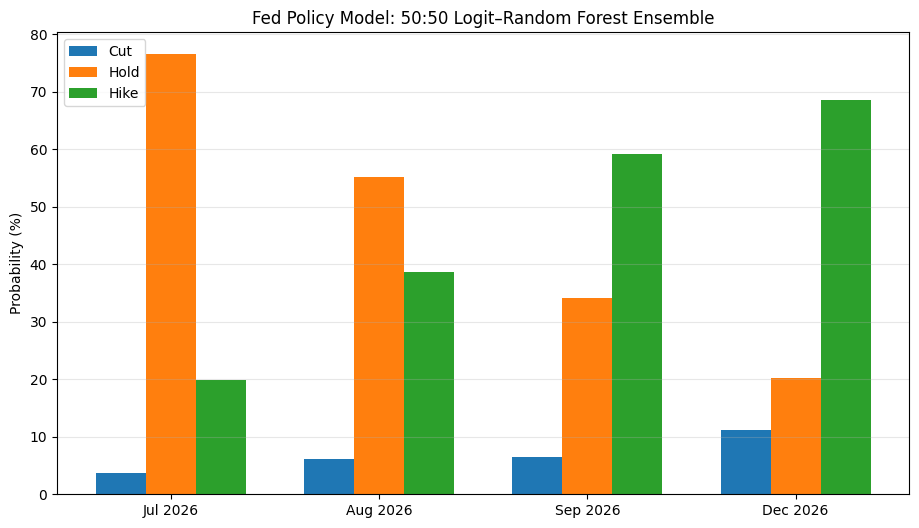

In [96]:

# ============================================================
# 9. SINGLE-PANEL CHART: ENSEMBLE PROBABILITIES
# ============================================================

plot_df = rf_ensemble_forecast.copy()

x = np.arange(len(plot_df))
width = 0.24

plt.figure(figsize=(11, 6))

plt.bar(x - width, plot_df["Ensemble cut probability"], width, label="Cut")
plt.bar(x, plot_df["Ensemble hold probability"], width, label="Hold")
plt.bar(x + width, plot_df["Ensemble hike probability"], width, label="Hike")

plt.xticks(x, plot_df["Forecast end month"])
plt.ylabel("Probability (%)")
plt.title("Fed Policy Model: 50:50 Logit–Random Forest Ensemble")
plt.grid(True, axis="y", alpha=0.30)
plt.legend()
plt.show()


In [97]:

# ============================================================
# 10. SAVE ROBUSTNESS OUTPUTS
# ============================================================

robustness_summary.to_csv(
    f"{DATA_DIR}/fed_policy_rf_ensemble_backtest_summary.csv",
    index=False
)

best_by_horizon.to_csv(
    f"{DATA_DIR}/fed_policy_rf_ensemble_best_by_horizon.csv",
    index=False
)

rf_ensemble_forecast.to_csv(
    f"{DATA_DIR}/fed_policy_rf_ensemble_forecast.csv",
    index=False
)

rf_importance.to_csv(
    f"{DATA_DIR}/fed_policy_rf_feature_importance_2m.csv",
    index=False
)

for h, bt in rf_ensemble_backtests.items():
    if not bt.empty:
        bt.to_csv(
            f"{DATA_DIR}/fed_policy_rf_ensemble_backtest_{h}m.csv"
        )

print("Saved RF and ensemble robustness outputs to:", DATA_DIR)


Saved RF and ensemble robustness outputs to: fed_policy_data
